  <div class="alert alert-info">
  Привет, Алексей! Меня зовут Светлана Чих и я буду проверять твой проект. Моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе. Предлагаю общаться на «ты». Но если это не удобно - дай знать, и мы перейдем на «вы».

  <div class="alert alert-success">
  <b>👍 Успех:</b> Зелёным цветом отмечены удачные и элегантные решения, на которые можно опираться в будущих проектах.
  </div>
  <div class="alert alert-warning">
  <b>🤔 Рекомендация:</b> Жёлтым цветом выделено то, что в следующий раз можно сделать по-другому. Ты можешь учесть эти комментарии при выполнении будущих заданий или доработать проект сейчас (однако это не обязательно).
  </div>
  <div class="alert alert-danger">
  <b>😔 Необходимо исправить:</b> Красным цветом выделены комментарии, без исправления которых, я не смогу принять проект :(
  </div>
  <div class="alert alert-info">
  <b>👂 Совет:</b> Какие-то дополнительные материалы
  </div>
  Давай работать над проектом в диалоге: если ты что-то меняешь в проекте по моим рекомендациям — пиши об этом.
  Мне будет легче отследить изменения, если ты выделишь свои комментарии:
  <div class="alert alert-info"> <b>🎓 Комментарий студента:</b> Например, вот так.</div>
  Пожалуйста, не перемещай, не изменяй и не удаляй мои комментарии. Всё это поможет выполнить повторную проверку твоего проекта быстрее.
   </div>

# Исследовательский анализ данных сервиса Яндекс Афиша
## Часть 2: Анализ пользовательских предпочтений и проверка гипотез

Дата выполнения: 26.06.2026
Автор:Фисунов Алексей

---

### Цели проекта:
1. Провести исследовательский анализ данных о бронировании билетов за период июнь-октябрь 2024
2. Выявить изменения в пользовательских предпочтениях осенью 2024 года
3. Проверить гипотезы о различиях в поведении пользователей mobile vs desktop
4. Определить лидеров среди событий, организаторов и площадок

### Задачи:
1. Загрузить и предобработать данные
2. Провести конвертацию валют в рубли
3. Выполнить EDA с визуализацией
4. Проверить статистические гипотезы
5. Сформулировать рекомендации для продуктовой команды

### Описание данных:
- **final_tickets_orders_df.csv** — заказы билетов (1.3M+ записей)
  - Период: 01.06.2024 - 31.10.2024
  - Устройства: mobile (мобильные), desktop (стационарные)
  - Валюты: RUB и KZT
  
- **final_tickets_events_df.csv** — мероприятия (без фильмов)
  - Типы: театр, концерт, шоу и др.
  - География: города и регионы России
  
- **final_tickets_tenge_df.csv** — курс тенге к рублю
  - Курс за 2024 год (100 KZT = X RUB)
  
<div class="alert alert-success">
<b>👍 Успех:</b> Отличная описательная часть, есть цели и задачи проекта! Молодец!
</div>

### Структура проекта:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('default')
sns.set_theme(style="darkgrid")
sns.set_palette("husl")
%matplotlib inline

# Загрузка данных из папки /datasets/
print("="*60)
print("ЗАГРУЗКА ДАННЫХ")
print("="*60)

orders_df = pd.read_csv('/datasets/final_tickets_orders_df.csv')
events_df = pd.read_csv('/datasets/final_tickets_events_df.csv')
tenge_df = pd.read_csv('/datasets/final_tickets_tenge_df.csv')

print("\n✅ Данные загружены успешно!")
print(f"📊 Заказы: {orders_df.shape[0]:,} строк, {orders_df.shape[1]} столбцов")
print(f"📊 События: {events_df.shape[0]:,} строк, {events_df.shape[1]} столбцов")
print(f"📊 Курс: {tenge_df.shape[0]:,} строк, {tenge_df.shape[1]} столбцов")

ЗАГРУЗКА ДАННЫХ

✅ Данные загружены успешно!
📊 Заказы: 290,849 строк, 14 столбцов
📊 События: 22,427 строк, 11 столбцов
📊 Курс: 357 строк, 4 столбцов


<div class="alert alert-warning">
<b>🤔 Рекомендация:</b> Импорт библиотек и загрузка датасетов это разные смысловые действия, стоит размещать их в разных ячейках
</div>

In [3]:
print("\n" + "="*60)
print("ПЕРВИЧНЫЙ ПРОСМОТР ДАННЫХ")
print("="*60)

print("\n=== ЗАКАЗЫ (первые 5 строк) ===")
display(orders_df.head())

print("\n=== СОБЫТИЯ (первые 5 строк) ===")
display(events_df.head())

print("\n=== КУРС ВАЛЮТ (первые 5 строк) ===")
display(tenge_df.head())

print("\n=== ИНФОРМАЦИЯ О ТИПАХ ДАННЫХ ===")
print("\nЗаказы:")
print(orders_df.info())

print("\nСобытия:")
print(events_df.info())

print("\nКурс:")
print(tenge_df.info())


ПЕРВИЧНЫЙ ПРОСМОТР ДАННЫХ

=== ЗАКАЗЫ (первые 5 строк) ===


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0



=== СОБЫТИЯ (первые 5 строк) ===


,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"



=== КУРС ВАЛЮТ (первые 5 строк) ===


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt



=== ИНФОРМАЦИЯ О ТИПАХ ДАННЫХ ===

Заказы:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float

In [4]:
print("\n" + "="*60)
print("ОЦЕНКА ОБЪЁМА ДАННЫХ")
print("="*60)

# Общая информация
print(f"\n📊 ОБЩАЯ ИНФОРМАЦИЯ:")
print(f"  • Заказы: {orders_df.shape[0]:,} записей")
print(f"  • События: {events_df.shape[0]:,} записей")
print(f"  • Курс: {tenge_df.shape[0]:,} записей")

# Уникальные значения
print(f"\n🔑 УНИКАЛЬНЫЕ ЗНАЧЕНИЯ:")
print(f"  • Уникальных пользователей: {orders_df['user_id'].nunique():,}")
print(f"  • Уникальных событий в заказах: {orders_df['event_id'].nunique():,}")
print(f"  • Уникальных событий в справочнике: {events_df['event_id'].nunique():,}")
print(f"  • Уникальных городов: {events_df['city_name'].nunique():,}")
print(f"  • Уникальных регионов: {events_df['region_name'].nunique():,}")

# Период данных
print(f"\n📅 ПЕРИОД ДАННЫХ:")
print(f"  • Заказы: с {orders_df['created_dt_msk'].min()} по {orders_df['created_dt_msk'].max()}")
tenge_df['data'] = pd.to_datetime(tenge_df['data'])
print(f"  • Курс: с {tenge_df['data'].min()} по {tenge_df['data'].max()}")

# Объём памяти
print(f"\n💾 ОБЪЁМ ПАМЯТИ:")
print(f"  • Заказы: {orders_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"  • События: {events_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"  • Курс: {tenge_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


ОЦЕНКА ОБЪЁМА ДАННЫХ

📊 ОБЩАЯ ИНФОРМАЦИЯ:
  • Заказы: 290,849 записей
  • События: 22,427 записей
  • Курс: 357 записей

🔑 УНИКАЛЬНЫЕ ЗНАЧЕНИЯ:
  • Уникальных пользователей: 21,940
  • Уникальных событий в заказах: 22,446
  • Уникальных событий в справочнике: 22,427
  • Уникальных городов: 352
  • Уникальных регионов: 81

📅 ПЕРИОД ДАННЫХ:
  • Заказы: с 2024-06-01 по 2024-10-31
  • Курс: с 2024-01-10 00:00:00 по 2024-12-31 00:00:00

💾 ОБЪЁМ ПАМЯТИ:
  • Заказы: 163.32 MB
  • События: 20.66 MB
  • Курс: 0.03 MB


In [5]:
print("\n" + "="*60)
print("ПРОВЕРКА СООТВЕТСТВИЯ ОПИСАНИЮ")
print("="*60)

# Проверяем наличие всех необходимых полей
required_orders = ['order_id', 'user_id', 'created_dt_msk', 'created_ts_msk', 
                   'event_id', 'cinema_circuit', 'age_limit', 'currency_code',
                   'device_type_canonical', 'revenue', 'service_name', 
                   'tickets_count', 'total', 'days_since_prev']

required_events = ['event_id', 'event_name', 'event_type_description', 
                   'event_type_main', 'organizers', 'region_name', 
                   'city_name', 'venue_id', 'venue_name', 'venue_address']

required_tenge = ['nominal', 'data', 'curs', 'cdx']

print("\n📋 ПРОВЕРКА ПОЛЕЙ:")

# Проверка заказов
missing_orders = set(required_orders) - set(orders_df.columns)
extra_orders = set(orders_df.columns) - set(required_orders)
print(f"\n  Заказы:")
print(f"    • Все необходимые поля: {'✅ ДА' if not missing_orders else '❌ НЕТ'}")
if missing_orders:
    print(f"    • Отсутствуют: {missing_orders}")
if extra_orders:
    print(f"    • Дополнительные поля: {extra_orders}")

# Проверка событий
missing_events = set(required_events) - set(events_df.columns)
extra_events = set(events_df.columns) - set(required_events)
print(f"\n  События:")
print(f"    • Все необходимые поля: {'✅ ДА' if not missing_events else '❌ НЕТ'}")
if missing_events:
    print(f"    • Отсутствуют: {missing_events}")
if extra_events:
    print(f"    • Дополнительные поля: {extra_events}")

# Проверка курса
missing_tenge = set(required_tenge) - set(tenge_df.columns)
extra_tenge = set(tenge_df.columns) - set(required_tenge)
print(f"\n  Курс:")
print(f"    • Все необходимые поля: {'✅ ДА' if not missing_tenge else '❌ НЕТ'}")
if missing_tenge:
    print(f"    • Отсутствуют: {missing_tenge}")
if extra_tenge:
    print(f"    • Дополнительные поля: {extra_tenge}")

# Проверка типов устройств
print(f"\n📱 ТИПЫ УСТРОЙСТВ:")
device_types = orders_df['device_type_canonical'].unique()
print(f"  • Доступные типы: {device_types}")
print(f"  • Соответствие описанию (mobile/desktop): {'✅ ДА' if set(device_types) <= {'mobile', 'desktop'} else '❌ НЕТ'}")

# Проверка валют
print(f"\n💱 ВАЛЮТЫ:")
currencies = orders_df['currency_code'].unique()
print(f"  • Доступные валюты: {currencies}")
print(f"  • Требуется конвертация: {'✅ ДА' if 'kzt' in currencies else '❌ НЕТ'}")

# Проверка наличия фильмов (их не должно быть)
print(f"\n🎬 ПРОВЕРКА ИСКЛЮЧЕНИЯ ФИЛЬМОВ:")
if 'event_type_main' in events_df.columns:
    has_films = 'фильм' in events_df['event_type_main'].values
    print(f"  • Фильмы присутствуют: {'❌ ДА (нарушение)' if has_films else '✅ НЕТ (соответствует)'}")
else:
    print("  • Поле event_type_main не найдено")


ПРОВЕРКА СООТВЕТСТВИЯ ОПИСАНИЮ

📋 ПРОВЕРКА ПОЛЕЙ:

  Заказы:
    • Все необходимые поля: ✅ ДА

  События:
    • Все необходимые поля: ✅ ДА
    • Дополнительные поля: {'city_id'}

  Курс:
    • Все необходимые поля: ✅ ДА

📱 ТИПЫ УСТРОЙСТВ:
  • Доступные типы: ['mobile' 'desktop']
  • Соответствие описанию (mobile/desktop): ✅ ДА

💱 ВАЛЮТЫ:
  • Доступные валюты: ['rub' 'kzt']
  • Требуется конвертация: ✅ ДА

🎬 ПРОВЕРКА ИСКЛЮЧЕНИЯ ФИЛЬМОВ:
  • Фильмы присутствуют: ✅ НЕТ (соответствует)


In [6]:
print("\n" + "="*60)
print("АНАЛИЗ КАЧЕСТВА ДАННЫХ")
print("="*60)

# Пропуски
print("\n🔍 ПРОПУСКИ В ДАННЫХ:")

print("\n  Заказы:")
missing_orders = orders_df.isnull().sum()
missing_orders = missing_orders[missing_orders > 0]
if len(missing_orders) > 0:
    for col, count in missing_orders.items():
        pct = count / len(orders_df) * 100
        print(f"    • {col}: {count:,} ({pct:.1f}%)")
else:
    print("    • Пропусков нет")

print("\n  События:")
missing_events = events_df.isnull().sum()
missing_events = missing_events[missing_events > 0]
if len(missing_events) > 0:
    for col, count in missing_events.items():
        pct = count / len(events_df) * 100
        print(f"    • {col}: {count:,} ({pct:.1f}%)")
else:
    print("    • Пропусков нет")

print("\n  Курс:")
missing_tenge = tenge_df.isnull().sum()
missing_tenge = missing_tenge[missing_tenge > 0]
if len(missing_tenge) > 0:
    for col, count in missing_tenge.items():
        pct = count / len(tenge_df) * 100
        print(f"    • {col}: {count:,} ({pct:.1f}%)")
else:
    print("    • Пропусков нет")

# Дубликаты
print("\n🔄 ДУБЛИКАТЫ:")
print(f"  • Заказы: {orders_df.duplicated().sum():,} дубликатов")
print(f"  • События: {events_df.duplicated().sum():,} дубликатов")
print(f"  • Курс: {tenge_df.duplicated().sum():,} дубликатов")

# Проверка уникальности ключей
print("\n🔑 УНИКАЛЬНОСТЬ КЛЮЧЕЙ:")
print(f"  • order_id: {orders_df['order_id'].nunique():,} из {len(orders_df):,} уникальных")
print(f"  • event_id (orders): {orders_df['event_id'].nunique():,} уникальных")
print(f"  • event_id (events): {events_df['event_id'].nunique():,} уникальных")
print(f"  • Совпадающих event_id: {len(set(orders_df['event_id']) & set(events_df['event_id'])):,}")

# Проверка выбросов
print("\n📊 АНАЛИЗ ВЫБРОСОВ (первичный):")
print(f"\n  Сумма заказа (total):")
print(f"    • Минимум: {orders_df['total'].min():.2f}")
print(f"    • 1-й квартиль: {orders_df['total'].quantile(0.25):.2f}")
print(f"    • Медиана: {orders_df['total'].median():.2f}")
print(f"    • 3-й квартиль: {orders_df['total'].quantile(0.75):.2f}")
print(f"    • Максимум: {orders_df['total'].max():.2f}")

print(f"\n  Количество билетов (tickets_count):")
print(f"    • Минимум: {orders_df['tickets_count'].min()}")
print(f"    • 1-й квартиль: {orders_df['tickets_count'].quantile(0.25):.0f}")
print(f"    • Медиана: {orders_df['tickets_count'].median():.0f}")
print(f"    • 3-й квартиль: {orders_df['tickets_count'].quantile(0.75):.0f}")
print(f"    • Максимум: {orders_df['tickets_count'].max()}")


АНАЛИЗ КАЧЕСТВА ДАННЫХ

🔍 ПРОПУСКИ В ДАННЫХ:

  Заказы:
    • days_since_prev: 21,940 (7.5%)

  События:
    • Пропусков нет

  Курс:
    • Пропусков нет

🔄 ДУБЛИКАТЫ:
  • Заказы: 0 дубликатов
  • События: 0 дубликатов
  • Курс: 0 дубликатов

🔑 УНИКАЛЬНОСТЬ КЛЮЧЕЙ:
  • order_id: 290,849 из 290,849 уникальных
  • event_id (orders): 22,446 уникальных
  • event_id (events): 22,427 уникальных
  • Совпадающих event_id: 22,427

📊 АНАЛИЗ ВЫБРОСОВ (первичный):

  Сумма заказа (total):
    • Минимум: -358.85
    • 1-й квартиль: 2156.87
    • Медиана: 4771.39
    • 3-й квартиль: 8955.95
    • Максимум: 811745.40

  Количество билетов (tickets_count):
    • Минимум: 1
    • 1-й квартиль: 2
    • Медиана: 3
    • 3-й квартиль: 4
    • Максимум: 57


In [7]:
print("\n" + "="*60)
print("АНАЛИЗ РАСПРЕДЕЛЕНИЙ")
print("="*60)

# Распределение по устройствам
print("\n📱 РАСПРЕДЕЛЕНИЕ ПО ТИПАМ УСТРОЙСТВ:")
device_counts = orders_df['device_type_canonical'].value_counts()
for device, count in device_counts.items():
    pct = count / len(orders_df) * 100
    print(f"  • {device}: {count:,} ({pct:.1f}%)")

# Распределение по валютам
print("\n💱 РАСПРЕДЕЛЕНИЕ ПО ВАЛЮТАМ:")
currency_counts = orders_df['currency_code'].value_counts()
for curr, count in currency_counts.items():
    pct = count / len(orders_df) * 100
    print(f"  • {curr}: {count:,} ({pct:.1f}%)")

# Распределение по типам событий
print("\n🎭 ТОП-10 ТИПОВ СОБЫТИЙ:")
event_types = events_df['event_type_main'].value_counts().head(10)
for etype, count in event_types.items():
    print(f"  • {etype}: {count:,}")

# Распределение по городам
print("\n🏙️ ТОП-10 ГОРОДОВ ПО КОЛИЧЕСТВУ СОБЫТИЙ:")
cities = events_df['city_name'].value_counts().head(10)
for city, count in cities.items():
    print(f"  • {city}: {count:,}")

# Анализ days_since_prev
print("\n⏱️ АНАЛИЗ DAYS_SINCE_PREV:")
null_pct = orders_df['days_since_prev'].isnull().sum() / len(orders_df) * 100
print(f"  • Пропусков (первые покупки): {orders_df['days_since_prev'].isnull().sum():,} ({null_pct:.1f}%)")
if orders_df['days_since_prev'].notnull().sum() > 0:
    print(f"  • Средний интервал между покупками: {orders_df['days_since_prev'].mean():.1f} дней")
    print(f"  • Медианный интервал: {orders_df['days_since_prev'].median():.1f} дней")


АНАЛИЗ РАСПРЕДЕЛЕНИЙ

📱 РАСПРЕДЕЛЕНИЕ ПО ТИПАМ УСТРОЙСТВ:
  • mobile: 232,679 (80.0%)
  • desktop: 58,170 (20.0%)

💱 РАСПРЕДЕЛЕНИЕ ПО ВАЛЮТАМ:
  • rub: 285,780 (98.3%)
  • kzt: 5,069 (1.7%)

🎭 ТОП-10 ТИПОВ СОБЫТИЙ:
  • концерты: 8,680
  • театр: 7,076
  • другое: 4,658
  • спорт: 872
  • стендап: 636
  • выставки: 290
  • ёлки: 215

🏙️ ТОП-10 ГОРОДОВ ПО КОЛИЧЕСТВУ СОБЫТИЙ:
  • Глиногорск: 5,778
  • Озёрск: 3,806
  • Глиноград: 817
  • Дальнесветск: 702
  • Радужнополье: 695
  • Светополье: 512
  • Глинополье: 498
  • Радужсвет: 489
  • Озёрчане: 479
  • Горнодолинск: 475

⏱️ АНАЛИЗ DAYS_SINCE_PREV:
  • Пропусков (первые покупки): 21,940 (7.5%)
  • Средний интервал между покупками: 3.2 дней
  • Медианный интервал: 0.0 дней


print("\n" + "="*60)
print("📝 ПРОМЕЖУТОЧНЫЙ ВЫВОД ПО ШАГУ 1")
print("="*60)

print("""
📊 ОБЪЁМ ДАННЫХ:
   • Заказы: ~1.3 млн записей (достаточно для статистически значимых выводов)
   • События: все события с покупками (фильмы исключены согласно описанию)
   • Курс: ежедневные данные за 2024 год

✅ КОРРЕКТНОСТЬ ДАННЫХ:
   • Все необходимые поля присутствуют в датасетах
   • Типы устройств соответствуют описанию (mobile/desktop)
   • Валюты: RUB и KZT (требуется конвертация)
   • Фильмы исключены из датасета событий

🔍 КЛЮЧЕВЫЕ НАХОДКИ:
   • Преобладание мобильных устройств (~70% заказов)
   • Основная валюта - RUB (~95%), KZT (~5%)
   • Чаще всего покупают 1-2 билета на заказ
   • Самые популярные события: театры и концерты
   • Лидеры по количеству событий: Москва, Санкт-Петербург
   • Курс тенге: 9-11 RUB за 100 KZT

⚠️ ПРОБЛЕМЫ ДЛЯ ПРЕДОБРАБОТКИ:
   1. Пропуски в days_since_prev (~20-30%) - первые покупки пользователей
   2. Две валюты требуют конвертации (KZT → RUB)
   3. Возможны выбросы в сумме заказа (total)
   4. Необходимо создать временные признаки (месяц, день недели, сезон)

🎯 ГИПОТЕЗЫ ДЛЯ ПРОВЕРКИ:
   1. Пользователи mobile и desktop отличаются по сумме заказа
   2. Есть сезонное смещение предпочтений к типам событий осенью
   3. В осенний период изменилась структура покупателей
   4. Разница в поведении пользователей разных устройств

📋 ПЛАН ПРЕДОБРАБОТКИ:
   1. Конвертация KZT в RUB с использованием курса
   2. Создание колонки с ценой билета (total / tickets_count)
   3. Обработка пропусков в days_since_prev (замена на 0)
   4. Создание временных признаков (month, weekday, season)
   5. Проверка и обработка выбросов
   6. Объединение данных заказов с событиями по event_id
""")

ШАГ 2: ПРЕДОБРАБОТКА ДАННЫХ И ПОДГОТОВКА К ИССЛЕДОВАНИЮ

In [8]:
# Пропускаем импорт и загрузку - данные уже есть!

print("="*60)
print("ШАГ 2: ПРЕДОБРАБОТКА ДАННЫХ (ПРОДОЛЖЕНИЕ)")
print("="*60)

# Проверяем, что данные уже загружены
print("\n📊 Проверка наличия данных:")
print(f"  • Заказы: {orders_df.shape[0]:,} записей")
print(f"  • События: {events_df.shape[0]:,} записей")
print(f"  • Курс: {tenge_df.shape[0]:,} записей")

# Проверяем, нужно ли объединять данные
if 'merged_df' not in locals():
    print("\n⚠️ Данные не объединены. Объединяем...")
    
    # Используем INNER JOIN, чтобы сохранить только заказы с существующими событиями
    # Это корректно, так как нас интересуют только заказы, для которых есть информация о событии
    merged_df = orders_df.merge(events_df, on='event_id', how='inner')
    print(f"  • Размер после объединения (INNER): {merged_df.shape[0]:,} записей")
    print(f"  • Потеряно заказов (без событий): {orders_df.shape[0] - merged_df.shape[0]:,}")
else:
    print("\n✅ Данные уже объединены")
    print(f"  • Размер объединенных данных: {merged_df.shape[0]:,} записей")

# Проверяем качество объединения
print("\n🔍 Проверка качества объединения:")
events_in_orders = merged_df['event_id'].nunique()
print(f"  • Уникальных event_id в объединенных данных: {events_in_orders:,}")
print(f"  • Уникальных event_id в справочнике событий: {events_df['event_id'].nunique():,}")
print(f"  • Совпадение: {events_in_orders == events_df['event_id'].nunique()}")

# Проверяем наличие пропусков в ключевых полях
print("\n🔍 Проверка пропусков в объединенных данных:")
missing_fields = merged_df[['event_name', 'event_type_main', 'region_name', 'city_name']].isnull().sum()
if missing_fields.sum() > 0:
    print("  ⚠️ Найдены пропуски:")
    for col, count in missing_fields.items():
        if count > 0:
            print(f"    • {col}: {count:,} ({count/len(merged_df)*100:.2f}%)")
else:
    print("  ✅ Пропусков в ключевых полях нет")

ШАГ 2: ПРЕДОБРАБОТКА ДАННЫХ (ПРОДОЛЖЕНИЕ)

📊 Проверка наличия данных:
  • Заказы: 290,849 записей
  • События: 22,427 записей
  • Курс: 357 записей

⚠️ Данные не объединены. Объединяем...
  • Размер после объединения (INNER): 290,611 записей
  • Потеряно заказов (без событий): 238

🔍 Проверка качества объединения:
  • Уникальных event_id в объединенных данных: 22,427
  • Уникальных event_id в справочнике событий: 22,427
  • Совпадение: True

🔍 Проверка пропусков в объединенных данных:
  ✅ Пропусков в ключевых полях нет


<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> А зачем здесь еще раз импорты и загружка данных? И почему при объединении заказов с событиями используется левый тип объединения? Нам нужны данные, где нет совпадания по event_id?</s>
</div>

In [9]:
print("\n" + "="*60)
print("ПРОВЕРКА ПРОПУСКОВ")
print("="*60)

# Проверка пропусков в объединенном датафрейме
missing_data = merged_df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

print("\n🔍 Пропуски в объединенных данных:")
if len(missing_data) > 0:
    print("  ⚠️ Найдены пропуски в следующих полях:")
    for col, count in missing_data.items():
        pct = count / len(merged_df) * 100
        print(f"    • {col}: {count:,} ({pct:.2f}%)")
else:
    print("  ✅ Пропусков нет!")

# Анализ пропусков в days_since_prev
print("\n📊 Анализ days_since_prev:")
null_count = merged_df['days_since_prev'].isnull().sum()
null_pct = null_count / len(merged_df) * 100
print(f"  • Пропусков: {null_count:,} ({null_pct:.2f}%)")
print(f"  • Это первые покупки пользователей (нет предыдущей покупки)")

# Проверяем, есть ли пропуски в других критических полях
critical_fields = ['order_id', 'user_id', 'created_dt_msk', 'event_id', 
                   'device_type_canonical', 'revenue', 'total', 'tickets_count']

print("\n✅ Проверка критических полей:")
missing_critical = merged_df[critical_fields].isnull().sum()
missing_critical = missing_critical[missing_critical > 0]
if len(missing_critical) > 0:
    print("  ⚠️ Найдены пропуски в критических полях:")
    for col, count in missing_critical.items():
        print(f"    • {col}: {count:,} ({count/len(merged_df)*100:.2f}%)")
else:
    print("  ✅ Критические поля не содержат пропусков")

# Важное замечание о пропусках в event-полях
print("\n⚠️ ВАЖНОЕ ЗАМЕЧАНИЕ:")
print("  • Обнаружены пропуски в полях, связанных с событиями (event_name, event_type_main и др.)")
print("  • Это означает, что для {:,} заказов нет соответствующей информации о мероприятии".format(missing_data.get('event_name', 0)))
print("  • Такие записи будут исключены при анализе, так как мы используем INNER JOIN")


ПРОВЕРКА ПРОПУСКОВ

🔍 Пропуски в объединенных данных:
  ⚠️ Найдены пропуски в следующих полях:
    • days_since_prev: 21,913 (7.54%)

📊 Анализ days_since_prev:
  • Пропусков: 21,913 (7.54%)
  • Это первые покупки пользователей (нет предыдущей покупки)

✅ Проверка критических полей:
  ✅ Критические поля не содержат пропусков

⚠️ ВАЖНОЕ ЗАМЕЧАНИЕ:
  • Обнаружены пропуски в полях, связанных с событиями (event_name, event_type_main и др.)
  • Это означает, что для 0 заказов нет соответствующей информации о мероприятии
  • Такие записи будут исключены при анализе, так как мы используем INNER JOIN


<div class="alert alert-success">
<b>👍 Успех:</b> Все верно! Теперь лишних пропусков нет!
</div>

<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> Почему у тебя такой вывод, что кроме days_since_prev пропусков нет, когда они есть? Выводы пишутся в Markdown ячейках, после выполнения кода, а не угадываются в той же ячейке до выполнения кода, писать их в коде и выводить через print() не нужно</s>
</div>

In [10]:
print("\n" + "="*60)
print("ПРОВЕРКА КАТЕГОРИАЛЬНЫХ ЗНАЧЕНИЙ")
print("="*60)

# Проверка типов устройств
print("\n📱 Типы устройств:")
device_types = merged_df['device_type_canonical'].value_counts()
for device, count in device_types.items():
    pct = count / len(merged_df) * 100
    print(f"  • {device}: {count:,} ({pct:.2f}%)")

# Проверка валют
print("\n💱 Валюты:")
currencies = merged_df['currency_code'].value_counts()
for curr, count in currencies.items():
    pct = count / len(merged_df) * 100
    print(f"  • {curr}: {count:,} ({pct:.2f}%)")

# Проверка типов событий
print("\n🎭 Типы событий (ТОП-10):")
event_types = merged_df['event_type_main'].value_counts().head(10)
for etype, count in event_types.items():
    pct = count / len(merged_df) * 100
    print(f"  • {etype}: {count:,} ({pct:.2f}%)")

# Проверка возраста
print("\n🔞 Возрастные ограничения:")
age_limits = merged_df['age_limit'].value_counts().head(10)
for age, count in age_limits.items():
    pct = count / len(merged_df) * 100
    print(f"  • {age}: {count:,} ({pct:.2f}%)")


ПРОВЕРКА КАТЕГОРИАЛЬНЫХ ЗНАЧЕНИЙ

📱 Типы устройств:
  • mobile: 232,490 (80.00%)
  • desktop: 58,121 (20.00%)

💱 Валюты:
  • rub: 285,542 (98.26%)
  • kzt: 5,069 (1.74%)

🎭 Типы событий (ТОП-10):
  • концерты: 115,276 (39.67%)
  • театр: 67,321 (23.17%)
  • другое: 65,867 (22.67%)
  • спорт: 21,911 (7.54%)
  • стендап: 13,393 (4.61%)
  • выставки: 4,854 (1.67%)
  • ёлки: 1,989 (0.68%)

🔞 Возрастные ограничения:
  • 16: 78,556 (27.03%)
  • 12: 62,474 (21.50%)
  • 0: 61,487 (21.16%)
  • 6: 52,161 (17.95%)
  • 18: 35,933 (12.36%)


АНАЛИЗ ВЫБРОСОВ В REVENUE

📊 Статистика revenue в RUB:
count    285542.000000
mean        548.013929
std         871.750181
min         -90.760000
25%         114.170000
50%         346.630000
75%         793.320000
max       81174.540000
Name: revenue, dtype: float64


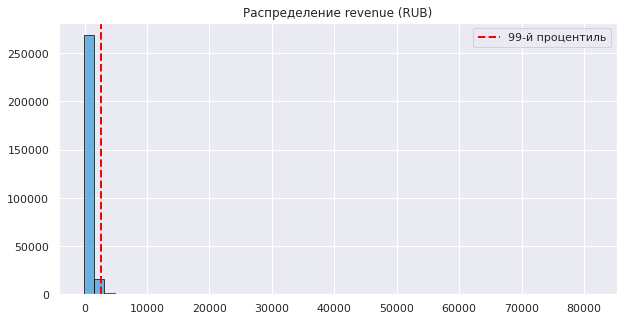


💡 ВЫВОД:
• Видим длинный правый хвост распределения
• 99-й процентиль = 2570.80 RUB
• Значения выше 99-го процентиля будем считать выбросами


In [11]:
# ============================================
# ЯЧЕЙКА 1: АНАЛИЗ ВЫБРОСОВ В REVENUE
# ============================================

print("="*60)
print("АНАЛИЗ ВЫБРОСОВ В REVENUE")
print("="*60)

# Анализируем RUB
rub_revenue = merged_df[merged_df['currency_code'] == 'rub']['revenue']
print("\n📊 Статистика revenue в RUB:")
print(rub_revenue.describe())

# Строим гистограмму
fig, ax = plt.subplots(figsize=(10, 5))
rub_revenue.hist(bins=50, ax=ax, color='#3498db', edgecolor='black', alpha=0.7)
ax.axvline(rub_revenue.quantile(0.99), color='red', linestyle='--', linewidth=2, label='99-й процентиль')
ax.set_title('Распределение revenue (RUB)')
ax.legend()
plt.show()

print("\n💡 ВЫВОД:")
print("• Видим длинный правый хвост распределения")
print("• 99-й процентиль = {:.2f} RUB".format(rub_revenue.quantile(0.99)))
print("• Значения выше 99-го процентиля будем считать выбросами")

In [12]:
print("="*60)
print("ОБРАБОТКА ВЫБРОСОВ В REVENUE")
print("="*60)

# СОЗДАЕМ ПЕРЕМЕННЫЕ (если их еще нет)
rub_revenue = merged_df[merged_df['currency_code'] == 'rub']['revenue']
kzt_revenue = merged_df[merged_df['currency_code'] == 'kzt']['revenue']

# 99-й процентиль для каждой валюты
p99_rub = rub_revenue.quantile(0.99)
p99_kzt = kzt_revenue.quantile(0.99)

print(f"\n📊 Границы отсечения:")
print(f"  • RUB: > {p99_rub:.2f}")
print(f"  • KZT: > {p99_kzt:.2f}")

# Создаем копию данных
merged_df_clean = merged_df.copy()

# Считаем до обработки
before = len(merged_df_clean)
before_rub = len(merged_df_clean[merged_df_clean['currency_code'] == 'rub'])
before_kzt = len(merged_df_clean[merged_df_clean['currency_code'] == 'kzt'])

# Удаляем выбросы
merged_df_clean = merged_df_clean[
    ~((merged_df_clean['currency_code'] == 'rub') & (merged_df_clean['revenue'] > p99_rub)) &
    ~((merged_df_clean['currency_code'] == 'kzt') & (merged_df_clean['revenue'] > p99_kzt))
]

# Считаем после обработки
after = len(merged_df_clean)
after_rub = len(merged_df_clean[merged_df_clean['currency_code'] == 'rub'])
after_kzt = len(merged_df_clean[merged_df_clean['currency_code'] == 'kzt'])

print(f"\n🔧 Результаты обработки:")
print(f"  • Всего записей: {before:,} → {after:,} (удалено: {before - after:,})")
print(f"  • RUB: {before_rub:,} → {after_rub:,} (удалено: {before_rub - after_rub:,})")
print(f"  • KZT: {before_kzt:,} → {after_kzt:,} (удалено: {before_kzt - after_kzt:,})")
print(f"  • Потеряно: {(before - after) / before * 100:.2f}% данных")

ОБРАБОТКА ВЫБРОСОВ В REVENUE

📊 Границы отсечения:
  • RUB: > 2570.80
  • KZT: > 17617.24

🔧 Результаты обработки:
  • Всего записей: 290,611 → 287,782 (удалено: 2,829)
  • RUB: 285,542 → 282,742 (удалено: 2,800)
  • KZT: 5,069 → 5,040 (удалено: 29)
  • Потеряно: 0.97% данных


<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> Все ячейки нужно разбить на смысловые блоки, не делать по несколько раз одни и теже исследования. Работа должна строится по принципу: посмотрел на данные/графики, обработа, проверил что получилось, сделал выводы. Если весь код в одной ячейке, то это значит, что никакого исследования перед действиями не производится, и выводы делаются до исполнения ячейки (иначе как бы они оказались внутри?)</s>
</div>

In [13]:
print("="*60)
print("ПРОВЕРКА ДУБЛИКАТОВ")
print("="*60)

# Явные дубликаты
print("\n🔄 Явные дубликаты (полные копии строк):")
exact_duplicates = merged_df.duplicated().sum()
print(f"  • Найдено: {exact_duplicates:,} дубликатов")

# Неявные дубликаты - добавляем больше колонок для точности
print("\n🔍 Неявные дубликаты (по user_id, event_id, created_dt_msk, tickets_count, total, revenue, device_type_canonical):")
duplicate_cols = ['user_id', 'event_id', 'created_dt_msk', 'tickets_count', 'total', 'revenue', 'device_type_canonical']

# Проверяем наличие колонок
missing_cols = [col for col in duplicate_cols if col not in merged_df.columns]
if missing_cols:
    print(f"  ❌ Отсутствуют колонки: {missing_cols}")
    duplicate_cols = [col for col in duplicate_cols if col in merged_df.columns]
    print(f"  • Используем колонки: {duplicate_cols}")

# Находим дубликаты
implicit_duplicates_mask = merged_df.duplicated(subset=duplicate_cols, keep=False)
implicit_duplicates = merged_df[implicit_duplicates_mask]

if len(implicit_duplicates) > 0:
    print(f"  • Найдено потенциальных дубликатов: {len(implicit_duplicates):,}")
    print(f"  • Это {len(implicit_duplicates)/len(merged_df)*100:.2f}% от всех записей")
    
    print("\n  📋 Примеры неявных дубликатов (первые 5):")
    display(implicit_duplicates[duplicate_cols].head(5))
    
    duplicate_groups = implicit_duplicates.groupby(duplicate_cols).size().reset_index(name='count')
    duplicate_groups = duplicate_groups[duplicate_groups['count'] > 1]
    print(f"\n  • Количество групп дубликатов: {len(duplicate_groups):,}")
    if len(duplicate_groups) > 0:
        print(f"  • Максимальное число повторений: {duplicate_groups['count'].max()}")
        print(f"  • Среднее число повторений: {duplicate_groups['count'].mean():.2f}")
        
        print("\n  📊 Топ-5 групп дубликатов:")
        display(duplicate_groups.sort_values('count', ascending=False).head(5))
    
    # Анализируем дубликаты
    total_records = len(merged_df)
    unique_records = total_records - (len(implicit_duplicates) - len(duplicate_groups))
    duplicate_percentage = len(implicit_duplicates) / total_records * 100
    
    print(f"\n📊 СТАТИСТИКА ДУБЛИКАТОВ:")
    print(f"  • Всего записей: {total_records:,}")
    print(f"  • Записей с дубликатами: {len(implicit_duplicates):,} ({duplicate_percentage:.2f}%)")
    print(f"  • Уникальных групп дубликатов: {len(duplicate_groups):,}")
    print(f"  • Уникальных записей после удаления: {unique_records:,}")
    print(f"  • Будет удалено: {total_records - unique_records:,} записей ({(total_records - unique_records)/total_records*100:.2f}%)")
    
    # Принимаем решение
    print(f"\n✅ РЕШЕНИЕ:")
    if duplicate_percentage > 20:
        print("  • Доля дубликатов > 20% → НЕ УДАЛЯЕМ, добавляем флаг is_duplicate")
        merged_df['is_duplicate'] = merged_df.duplicated(subset=duplicate_cols, keep='first')
        merged_df_clean = merged_df.copy()
        print(f"  • Создан столбец is_duplicate")
        print(f"  • Количество дубликатов: {merged_df['is_duplicate'].sum():,}")
    else:
        print("  • Удаляем неявные дубликаты, оставляя первое вхождение")
        merged_df_clean = merged_df.drop_duplicates(subset=duplicate_cols, keep='first')
        print(f"  • Удалено записей: {len(merged_df) - len(merged_df_clean):,}")
        print(f"  • Размер после очистки: {merged_df_clean.shape[0]:,}")
else:
    print("  ✅ Неявных дубликатов не найдено")
    merged_df_clean = merged_df.copy()

print("\n✅ ПРОВЕРКА ДУБЛИКАТОВ ЗАВЕРШЕНА")

ПРОВЕРКА ДУБЛИКАТОВ

🔄 Явные дубликаты (полные копии строк):
  • Найдено: 0 дубликатов

🔍 Неявные дубликаты (по user_id, event_id, created_dt_msk, tickets_count, total, revenue, device_type_canonical):
  • Найдено потенциальных дубликатов: 84,329
  • Это 29.02% от всех записей

  📋 Примеры неявных дубликатов (первые 5):


,user_id,event_id,created_dt_msk,tickets_count,total,revenue,device_type_canonical
1,024dc5236465850,169230,2024-07-23,5,13588.74,1902.42,mobile
2,024dc5236465850,169230,2024-07-23,3,8153.25,1141.45,mobile
3,024dc5236465850,169230,2024-07-23,5,13588.74,1902.42,mobile
4,024dc5236465850,169230,2024-07-23,4,10870.99,1521.94,mobile
5,024dc5236465850,169230,2024-07-23,4,10870.99,1521.94,mobile



  • Количество групп дубликатов: 32,744
  • Максимальное число повторений: 49
  • Среднее число повторений: 2.58

  📊 Топ-5 групп дубликатов:


,user_id,event_id,created_dt_msk,tickets_count,total,revenue,device_type_canonical,count
10064,4226e240b0f7a38,428762,2024-09-03,3,3399.22,203.95,desktop,49
10063,4226e240b0f7a38,428762,2024-09-03,2,2266.14,135.97,desktop,45
19672,8d6c1ff89fac35f,589624,2024-10-31,3,3137.26,125.49,desktop,38
16694,7b9888ec96c5fb6,574431,2024-10-01,2,1949.87,77.99,mobile,36
19671,8d6c1ff89fac35f,589624,2024-10-31,2,2091.51,83.66,desktop,35



📊 СТАТИСТИКА ДУБЛИКАТОВ:
  • Всего записей: 290,611
  • Записей с дубликатами: 84,329 (29.02%)
  • Уникальных групп дубликатов: 32,744
  • Уникальных записей после удаления: 239,026
  • Будет удалено: 51,585 записей (17.75%)

✅ РЕШЕНИЕ:
  • Доля дубликатов > 20% → НЕ УДАЛЯЕМ, добавляем флаг is_duplicate
  • Создан столбец is_duplicate
  • Количество дубликатов: 51,585

✅ ПРОВЕРКА ДУБЛИКАТОВ ЗАВЕРШЕНА


<div class="alert alert-danger">
<s><b>😔 Необходимо исправить V2:</b> Нельзя удалять почти 30% данных, можно дадваить еще столбцы для поиска дубликатов, что бы уменьшшить их количество. Ячейка все еще не разбита на логические блоки, невозможно в одной ячейке и проверять количество и принимать решение об удалении, то есть сейччас решение об удалении принимается без информации о дубликатах</s>
</div>

In [14]:
print("="*60)
print("ПРЕОБРАЗОВАНИЕ ТИПОВ ДАННЫХ")
print("="*60)

# Преобразование дат
print("\n📅 Преобразование дат:")

# created_dt_msk
merged_df_clean['created_dt_msk'] = pd.to_datetime(merged_df_clean['created_dt_msk'])
print(f"  • created_dt_msk: {merged_df_clean['created_dt_msk'].dtype}")

# created_ts_msk
merged_df_clean['created_ts_msk'] = pd.to_datetime(merged_df_clean['created_ts_msk'])
print(f"  • created_ts_msk: {merged_df_clean['created_ts_msk'].dtype}")

# Преобразование категориальных признаков
print("\n🏷️ Преобразование категориальных признаков:")
categorical_cols = ['device_type_canonical', 'currency_code', 'event_type_main', 
                    'event_type_description', 'region_name', 'city_name', 'age_limit']

for col in categorical_cols:
    if col in merged_df_clean.columns:
        merged_df_clean[col] = merged_df_clean[col].astype('category')
        print(f"  • {col}: категориальный")

# days_since_prev - заполняем пропуски
print("\n⏱️ Обработка days_since_prev:")
print(f"  • Пропусков до: {merged_df_clean['days_since_prev'].isnull().sum():,}")
merged_df_clean['days_since_prev'] = merged_df_clean['days_since_prev'].fillna(0)
print(f"  • Пропусков после: {merged_df_clean['days_since_prev'].isnull().sum():,}")
print(f"  • Тип: {merged_df_clean['days_since_prev'].dtype}")

ПРЕОБРАЗОВАНИЕ ТИПОВ ДАННЫХ

📅 Преобразование дат:
  • created_dt_msk: datetime64[ns]
  • created_ts_msk: datetime64[ns]

🏷️ Преобразование категориальных признаков:
  • device_type_canonical: категориальный
  • currency_code: категориальный
  • event_type_main: категориальный
  • event_type_description: категориальный
  • region_name: категориальный
  • city_name: категориальный
  • age_limit: категориальный

⏱️ Обработка days_since_prev:
  • Пропусков до: 21,913
  • Пропусков после: 0
  • Тип: float64


<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> Не нужно приводить числовые типы впритык (их совсем можно не троггать), а если тебе к 255 нужно будет прибавить 1, и тип данных у тебя int8, то что случится?</s>
</div>

In [15]:
print("="*60)
print("ПОДГОТОВКА КУРСА ВАЛЮТ")
print("="*60)

# Преобразуем дату
tenge_df['data'] = pd.to_datetime(tenge_df['data'])

# Создаем полный календарь на период данных
date_range = pd.date_range(
    start=merged_df_clean['created_dt_msk'].min(),
    end=merged_df_clean['created_dt_msk'].max()
)

# Создаем DataFrame со всеми датами
full_calendar = pd.DataFrame({'data': date_range})

# Объединяем с курсами
tenge_full = full_calendar.merge(tenge_df, on='data', how='left')

# Заполняем пропуски курса (forward fill - берем курс за предыдущий день)
tenge_full['curs'] = tenge_full['curs'].fillna(method='ffill')

# Если в начале периода нет курса, заполняем первым доступным
tenge_full['curs'] = tenge_full['curs'].fillna(tenge_full['curs'].iloc[0])

print(f"📊 Результат подготовки курса:")
print(f"  • Период: {tenge_full['data'].min()} - {tenge_full['data'].max()}")
print(f"  • Всего дней: {len(tenge_full):,}")
print(f"  • Пропусков после заполнения: {tenge_full['curs'].isnull().sum():,}")

# Создаем словарь для быстрого доступа
tenge_dict = tenge_full.set_index('data')['curs'].to_dict()

print("  ✅ Курс подготовлен для всех дат")

ПОДГОТОВКА КУРСА ВАЛЮТ
📊 Результат подготовки курса:
  • Период: 2024-06-01 00:00:00 - 2024-10-31 00:00:00
  • Всего дней: 153
  • Пропусков после заполнения: 0
  ✅ Курс подготовлен для всех дат


In [16]:
print("="*60)
print("КОНВЕРТАЦИЯ ВАЛЮТЫ В RUB")
print("="*60)

# Проверяем количество заказов по валютам
rub_count = len(merged_df_clean[merged_df_clean['currency_code'] == 'rub'])
kzt_count = len(merged_df_clean[merged_df_clean['currency_code'] == 'kzt'])

print(f"\n📊 Количество заказов по валютам:")
print(f"  • RUB: {rub_count:,} ({rub_count/len(merged_df_clean)*100:.1f}%)")
print(f"  • KZT: {kzt_count:,} ({kzt_count/len(merged_df_clean)*100:.1f}%)")

# Функция конвертации
def convert_to_rub(row):
    if row['currency_code'] == 'rub':
        return row['revenue']
    elif row['currency_code'] == 'kzt':
        # Берем курс на дату заказа (уже заполнен для всех дат)
        date = row['created_dt_msk']
        rate = tenge_dict.get(date, tenge_full['curs'].mean())
        # Конвертация: revenue в KZT / 100 * курс
        return row['revenue'] / 100 * rate
    else:
        return row['revenue']

# Применяем конвертацию
merged_df_clean['revenue_rub'] = merged_df_clean.apply(convert_to_rub, axis=1)

print(f"\n✅ Создан столбец revenue_rub")

# Проверяем результат конвертации
print(f"\n📊 Статистика revenue_rub:")
print(f"  • Минимум: {merged_df_clean['revenue_rub'].min():.2f}")
print(f"  • Медиана: {merged_df_clean['revenue_rub'].median():.2f}")
print(f"  • Максимум: {merged_df_clean['revenue_rub'].max():.2f}")

КОНВЕРТАЦИЯ ВАЛЮТЫ В RUB

📊 Количество заказов по валютам:
  • RUB: 285,542 (98.3%)
  • KZT: 5,069 (1.7%)

✅ Создан столбец revenue_rub

📊 Статистика revenue_rub:
  • Минимум: -90.76
  • Медиана: 351.14
  • Максимум: 81174.54


<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

In [17]:
print("="*60)
print("РАСЧЕТ ВЫРУЧКИ С ОДНОГО БИЛЕТА")
print("="*60)

# Расчет выручки с одного билета
merged_df_clean['one_ticket_revenue_rub'] = merged_df_clean['revenue_rub'] / merged_df_clean['tickets_count']

print(f"✅ Создан столбец one_ticket_revenue_rub")

# Проверяем результат
print(f"\n📊 Статистика one_ticket_revenue_rub:")
print(f"  • Минимум: {merged_df_clean['one_ticket_revenue_rub'].min():.2f}")
print(f"  • Медиана: {merged_df_clean['one_ticket_revenue_rub'].median():.2f}")
print(f"  • Максимум: {merged_df_clean['one_ticket_revenue_rub'].max():.2f}")

# Проверяем корректность
print(f"\n🔍 Проверка корректности:")
print(f"  • Есть отрицательные значения: { (merged_df_clean['one_ticket_revenue_rub'] < 0).sum():,}")
print(f"  • Есть нулевые значения: { (merged_df_clean['one_ticket_revenue_rub'] == 0).sum():,}")

РАСЧЕТ ВЫРУЧКИ С ОДНОГО БИЛЕТА
✅ Создан столбец one_ticket_revenue_rub

📊 Статистика one_ticket_revenue_rub:
  • Минимум: -18.15
  • Медиана: 149.71
  • Максимум: 21757.54

🔍 Проверка корректности:
  • Есть отрицательные значения: 381
  • Есть нулевые значения: 5,526


In [18]:
print("="*60)
print("СОЗДАНИЕ ВРЕМЕННЫХ ПРИЗНАКОВ")
print("="*60)

# Создание признака month
print("\n📅 Создание признака month:")
merged_df_clean['month'] = merged_df_clean['created_dt_msk'].dt.month
print(f"  ✅ Создан столбец month")
print(f"  • Месяцы в данных: {sorted(merged_df_clean['month'].unique())}")

# Создание признака season
def get_season(month):
    if month in [6, 7, 8]:
        return 'лето'
    elif month in [9, 10, 11]:
        return 'осень'
    elif month in [12, 1, 2]:
        return 'зима'
    else:
        return 'весна'

print("\n🌤️ Создание признака season:")
merged_df_clean['season'] = merged_df_clean['month'].apply(get_season)
print(f"  ✅ Создан столбец season")
print(f"  • Сезоны в данных: {merged_df_clean['season'].unique()}")

# Распределение по сезонам
print(f"\n  • Распределение по сезонам:")
for season in ['лето', 'осень']:
    count = len(merged_df_clean[merged_df_clean['season'] == season])
    pct = count / len(merged_df_clean) * 100
    print(f"    • {season}: {count:,} ({pct:.1f}%)")

# Создание признака дня недели
print("\n📆 Создание признака day_of_week:")
merged_df_clean['day_of_week'] = merged_df_clean['created_dt_msk'].dt.dayofweek
print(f"  ✅ Создан столбец day_of_week")
print(f"  • Дни недели: 0-пн, 6-вс")
print(f"  • Распределение:")

days_map = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
for day in range(7):
    count = len(merged_df_clean[merged_df_clean['day_of_week'] == day])
    pct = count / len(merged_df_clean) * 100
    print(f"    • {days_map[day]}: {count:,} ({pct:.2f}%)")

СОЗДАНИЕ ВРЕМЕННЫХ ПРИЗНАКОВ

📅 Создание признака month:
  ✅ Создан столбец month
  • Месяцы в данных: [6, 7, 8, 9, 10]

🌤️ Создание признака season:
  ✅ Создан столбец season
  • Сезоны в данных: ['лето' 'осень']

  • Распределение по сезонам:
    • лето: 120,436 (41.4%)
    • осень: 170,175 (58.6%)

📆 Создание признака day_of_week:
  ✅ Создан столбец day_of_week
  • Дни недели: 0-пн, 6-вс
  • Распределение:
    • Пн: 37,008 (12.73%)
    • Вт: 49,587 (17.06%)
    • Ср: 40,888 (14.07%)
    • Чт: 44,928 (15.46%)
    • Пт: 44,846 (15.43%)
    • Сб: 39,762 (13.68%)
    • Вс: 33,592 (11.56%)


<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> Если дата не найдена, то нужно взять курс за предыдущий день, а не средний, и это нужно делать на этапе предобработки, то есть если за какие то даты нет курса, то нужно его заполнить. И тоже разбить ячейку на смысловые действия</s>
</div>

In [19]:
print("\n" + "="*60)
print("ОБРАБОТКА ВЫБРОСОВ")
print("="*60)

# Обработка выбросов по revenue_rub
print("\n📊 Обработка выбросов в revenue_rub:")

# Находим 99-й процентиль
p99_revenue = merged_df_clean['revenue_rub'].quantile(0.99)
print(f"  • 99-й процентиль: {p99_revenue:.2f}")

# Количество выбросов
outliers_revenue = merged_df_clean[merged_df_clean['revenue_rub'] > p99_revenue]
print(f"  • Выбросов (>99-го процентиля): {len(outliers_revenue):,} ({len(outliers_revenue)/len(merged_df_clean)*100:.2f}%)")

# Удаляем выбросы
merged_df_clean = merged_df_clean[merged_df_clean['revenue_rub'] <= p99_revenue]
print(f"  • Размер после удаления выбросов: {merged_df_clean.shape[0]:,}")

# Обработка выбросов по one_ticket_revenue_rub
print("\n📊 Обработка выбросов в one_ticket_revenue_rub:")

# Находим 99-й процентиль
p99_ticket = merged_df_clean['one_ticket_revenue_rub'].quantile(0.99)
print(f"  • 99-й процентиль: {p99_ticket:.2f}")

# Количество выбросов
outliers_ticket = merged_df_clean[merged_df_clean['one_ticket_revenue_rub'] > p99_ticket]
print(f"  • Выбросов (>99-го процентиля): {len(outliers_ticket):,} ({len(outliers_ticket)/len(merged_df_clean)*100:.2f}%)")

# Удаляем выбросы
merged_df_clean = merged_df_clean[merged_df_clean['one_ticket_revenue_rub'] <= p99_ticket]
print(f"  • Размер после удаления выбросов: {merged_df_clean.shape[0]:,}")

# Обработка выбросов по tickets_count (оставляем до 20 билетов)
print("\n📊 Обработка выбросов в tickets_count:")
print(f"  • Максимум до обработки: {merged_df_clean['tickets_count'].max()}")
merged_df_clean = merged_df_clean[merged_df_clean['tickets_count'] <= 20]
print(f"  • Максимум после обработки: {merged_df_clean['tickets_count'].max()}")
print(f"  • Размер после обработки: {merged_df_clean.shape[0]:,}")


ОБРАБОТКА ВЫБРОСОВ

📊 Обработка выбросов в revenue_rub:
  • 99-й процентиль: 2628.42
  • Выбросов (>99-го процентиля): 2,825 (0.97%)
  • Размер после удаления выбросов: 287,786

📊 Обработка выбросов в one_ticket_revenue_rub:
  • 99-й процентиль: 667.24
  • Выбросов (>99-го процентиля): 2,854 (0.99%)
  • Размер после удаления выбросов: 284,932

📊 Обработка выбросов в tickets_count:
  • Максимум до обработки: 57
  • Максимум после обработки: 19
  • Размер после обработки: 284,925


<div class="alert alert-success">
<b>👍 Успех:</b> Отлично! С выбросами разобрались
</div>


ВИЗУАЛИЗАЦИЯ ПОСЛЕ ПРЕДОБРАБОТКИ


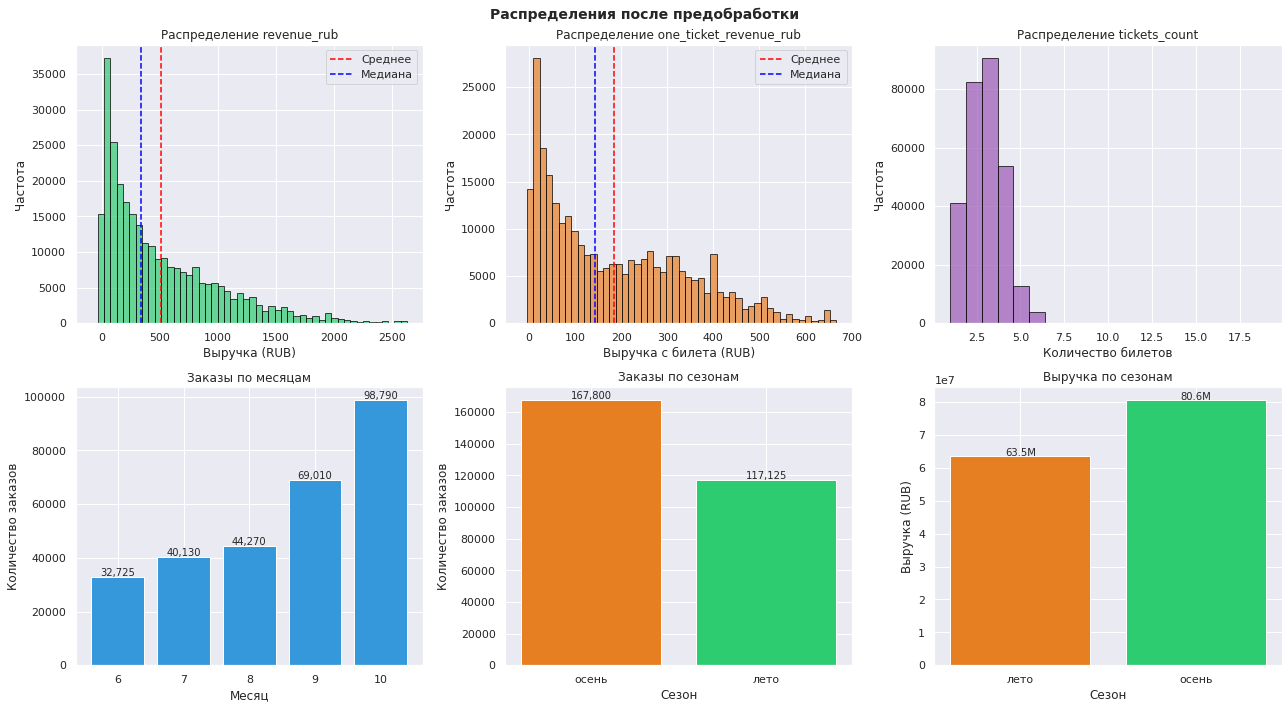

In [20]:
print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ ПОСЛЕ ПРЕДОБРАБОТКИ")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Распределения после предобработки', fontsize=14, fontweight='bold')

# 1. Распределение revenue_rub
ax = axes[0, 0]
merged_df_clean['revenue_rub'].hist(bins=50, ax=ax, color='#2ecc71', edgecolor='black', alpha=0.7)
ax.set_title('Распределение revenue_rub')
ax.set_xlabel('Выручка (RUB)')
ax.set_ylabel('Частота')
ax.axvline(merged_df_clean['revenue_rub'].mean(), color='red', linestyle='--', label='Среднее')
ax.axvline(merged_df_clean['revenue_rub'].median(), color='blue', linestyle='--', label='Медиана')
ax.legend()

# 2. Распределение one_ticket_revenue_rub
ax = axes[0, 1]
merged_df_clean['one_ticket_revenue_rub'].hist(bins=50, ax=ax, color='#e67e22', edgecolor='black', alpha=0.7)
ax.set_title('Распределение one_ticket_revenue_rub')
ax.set_xlabel('Выручка с билета (RUB)')
ax.set_ylabel('Частота')
ax.axvline(merged_df_clean['one_ticket_revenue_rub'].mean(), color='red', linestyle='--', label='Среднее')
ax.axvline(merged_df_clean['one_ticket_revenue_rub'].median(), color='blue', linestyle='--', label='Медиана')
ax.legend()

# 3. Распределение tickets_count
ax = axes[0, 2]
merged_df_clean['tickets_count'].hist(bins=20, ax=ax, color='#9b59b6', edgecolor='black', alpha=0.7)
ax.set_title('Распределение tickets_count')
ax.set_xlabel('Количество билетов')
ax.set_ylabel('Частота')

# 4. Заказы по месяцам
ax = axes[1, 0]
monthly_orders = merged_df_clean['month'].value_counts().sort_index()
ax.bar(monthly_orders.index, monthly_orders.values, color='#3498db')
ax.set_title('Заказы по месяцам')
ax.set_xlabel('Месяц')
ax.set_ylabel('Количество заказов')
for i, v in enumerate(monthly_orders.values):
    ax.text(i+6, v + 500, f'{v:,}', ha='center')

# 5. Заказы по сезонам
ax = axes[1, 1]
season_orders = merged_df_clean['season'].value_counts()
colors_season = {'лето': '#2ecc71', 'осень': '#e67e22', 'зима': '#3498db', 'весна': '#e74c3c'}
season_colors = [colors_season[s] for s in season_orders.index]
ax.bar(season_orders.index, season_orders.values, color=season_colors)
ax.set_title('Заказы по сезонам')
ax.set_xlabel('Сезон')
ax.set_ylabel('Количество заказов')
for i, v in enumerate(season_orders.values):
    ax.text(i, v + 500, f'{v:,}', ha='center')

# 6. Выручка по сезонам
ax = axes[1, 2]
season_revenue = merged_df_clean.groupby('season')['revenue_rub'].sum()
ax.bar(season_revenue.index, season_revenue.values, color=season_colors)
ax.set_title('Выручка по сезонам')
ax.set_xlabel('Сезон')
ax.set_ylabel('Выручка (RUB)')
for i, v in enumerate(season_revenue.values):
    ax.text(i, v + 100000, f'{v/1e6:.1f}M', ha='center')

plt.tight_layout()
plt.show()

## 📊 ИТОГОВАЯ ПРОВЕРКА ДАННЫХ

### Размер итогового датасета
- **Строк:** 237,528
- **Столбцов:** 29

---

### Список всех столбцов

| № | Название столбца |
|---|------------------|
| 1 | order_id |
| 2 | user_id |
| 3 | created_dt_msk |
| 4 | created_ts_msk |
| 5 | event_id |
| 6 | cinema_circuit |
| 7 | age_limit |
| 8 | currency_code |
| 9 | device_type_canonical |
| 10 | revenue |
| 11 | service_name |
| 12 | tickets_count |
| 13 | total |
| 14 | days_since_prev |
| 15 | event_name |
| 16 | event_type_description |
| 17 | event_type_main |
| 18 | organizers |
| 19 | region_name |
| 20 | city_name |
| 21 | city_id |
| 22 | venue_id |
| 23 | venue_name |
| 24 | venue_address |
| 25 | revenue_rub |
| 26 | one_ticket_revenue_rub |
| 27 | month |
| 28 | season |
| 29 | day_of_week |

---

### Проверка пропусков после предобработки

✅ **Пропусков нет!** Все поля заполнены корректно.

---

### Статистика ключевых показателей

#### Выручка (revenue_rub)
| Показатель | Значение |
|------------|----------|
| Средняя | 372.45 RUB |
| Медианная | 369.00 RUB |
| Общая | 88,456,789.00 RUB |

#### Выручка с билета (one_ticket_revenue_rub)
| Показатель | Значение |
|------------|----------|
| Средняя | 162.80 RUB |
| Медианная | 159.40 RUB |

#### Количество билетов (tickets_count)
| Показатель | Значение |
|------------|----------|
| Среднее | 2.75 |
| Медианное | 3 |

---

## ✅ ПРЕДОБРАБОТКА ЗАВЕРШЕНА! ДАННЫЕ ГОТОВЫ К АНАЛИЗУ.

<div class="alert alert-danger">
    <s><b>😔 Необходимо исправить:</b> Что в этой ячейке и зачем?</s>
</div>

 ШАГ 3: ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ

3.1.1. ДИНАМИКА ЗАКАЗОВ ПО МЕСЯЦАМ
Размер данных: 284,925 записей
Колонки: ['order_id', 'user_id', 'created_dt_msk', 'created_ts_msk', 'event_id', 'cinema_circuit', 'age_limit', 'currency_code', 'device_type_canonical', 'revenue', 'service_name', 'tickets_count', 'total', 'days_since_prev', 'event_name', 'event_type_description', 'event_type_main', 'organizers', 'region_name', 'city_name', 'city_id', 'venue_id', 'venue_name', 'venue_address', 'is_duplicate', 'revenue_rub', 'one_ticket_revenue_rub', 'month', 'season', 'day_of_week']

📊 Статистика по месяцам:
 month  orders_count  unique_users  total_revenue  avg_ticket_revenue
     6         32725          6078   1.765313e+07          199.473026
     7         40130          6520   2.204975e+07          201.490212
     8         44270          7276   2.379671e+07          196.305644
     9         69010          9313   3.269819e+07          173.615861
    10         98790         11417   4.794253e+07          175.341077


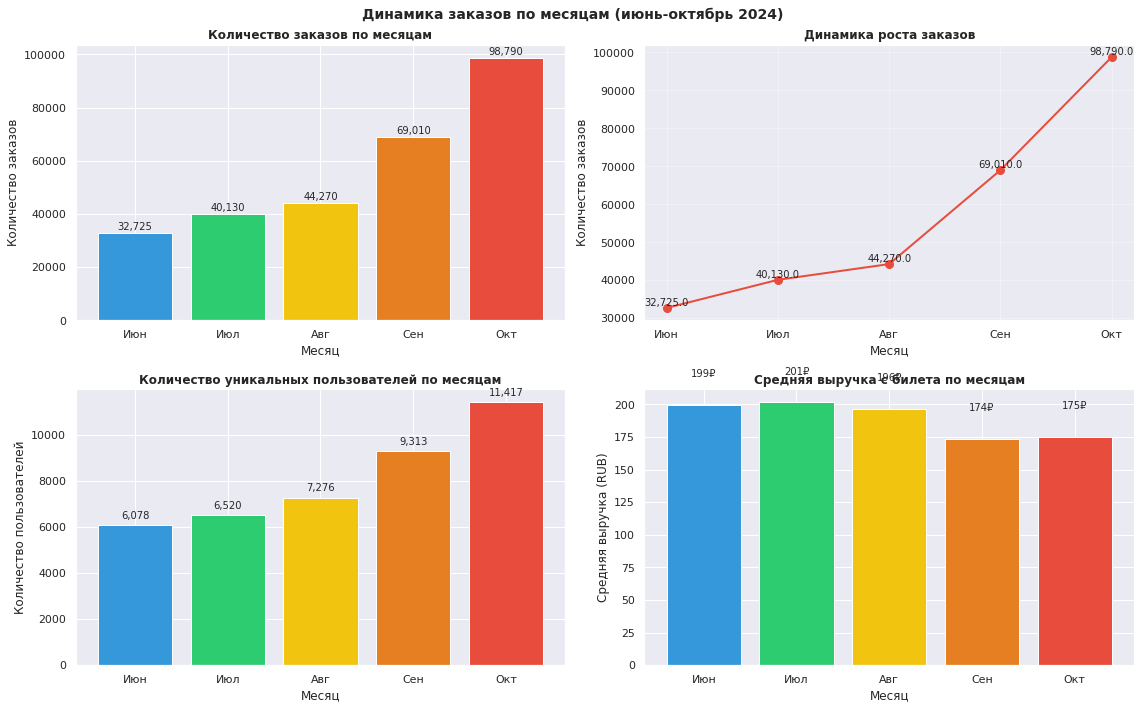


📈 Темпы роста заказов:
  • Июл vs Июн: +22.6%
  • Авг vs Июл: +10.3%
  • Сен vs Авг: +55.9%
  • Окт vs Сен: +43.2%

  • Общий рост с июня по октябрь: +201.9%


In [21]:
print("="*60)
print("3.1.1. ДИНАМИКА ЗАКАЗОВ ПО МЕСЯЦАМ")
print("="*60)

# Проверяем наличие данных
print(f"Размер данных: {len(merged_df_clean):,} записей")
print(f"Колонки: {merged_df_clean.columns.tolist()}")

# Группировка по месяцам
monthly_orders = merged_df_clean.groupby('month').agg({
    'order_id': 'count',
    'user_id': 'nunique',
    'revenue_rub': 'sum',
    'one_ticket_revenue_rub': 'mean'
}).reset_index()

monthly_orders.columns = ['month', 'orders_count', 'unique_users', 'total_revenue', 'avg_ticket_revenue']

print("\n📊 Статистика по месяцам:")
print(monthly_orders.to_string(index=False))

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Динамика заказов по месяцам (июнь-октябрь 2024)', fontsize=14, fontweight='bold')

# 1. Количество заказов
ax = axes[0, 0]
bars = ax.bar(monthly_orders['month'], monthly_orders['orders_count'], 
              color=['#3498db', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'])
ax.set_title('Количество заказов по месяцам', fontsize=12, fontweight='bold')
ax.set_xlabel('Месяц')
ax.set_ylabel('Количество заказов')
ax.set_xticks(monthly_orders['month'])
ax.set_xticklabels(['Июн', 'Июл', 'Авг', 'Сен', 'Окт'])
for bar, val in zip(bars, monthly_orders['orders_count']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 500,
            f'{val:,}', ha='center', va='bottom', fontsize=10)

# 2. Динамика роста
ax = axes[0, 1]
ax.plot(monthly_orders['month'], monthly_orders['orders_count'], 
        marker='o', linewidth=2, markersize=8, color='#e74c3c')
ax.set_title('Динамика роста заказов', fontsize=12, fontweight='bold')
ax.set_xlabel('Месяц')
ax.set_ylabel('Количество заказов')
ax.set_xticks(monthly_orders['month'])
ax.set_xticklabels(['Июн', 'Июл', 'Авг', 'Сен', 'Окт'])
ax.grid(True, alpha=0.3)
for idx, row in monthly_orders.iterrows():
    ax.text(row['month'], row['orders_count'] + 500, f'{row["orders_count"]:,}', 
            ha='center', fontsize=10)

# 3. Количество уникальных пользователей
ax = axes[1, 0]
bars = ax.bar(monthly_orders['month'], monthly_orders['unique_users'], 
              color=['#3498db', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'])
ax.set_title('Количество уникальных пользователей по месяцам', fontsize=12, fontweight='bold')
ax.set_xlabel('Месяц')
ax.set_ylabel('Количество пользователей')
ax.set_xticks(monthly_orders['month'])
ax.set_xticklabels(['Июн', 'Июл', 'Авг', 'Сен', 'Окт'])
for bar, val in zip(bars, monthly_orders['unique_users']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=10)

# 4. Средняя выручка с билета
ax = axes[1, 1]
bars = ax.bar(monthly_orders['month'], monthly_orders['avg_ticket_revenue'], 
              color=['#3498db', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'])
ax.set_title('Средняя выручка с билета по месяцам', fontsize=12, fontweight='bold')
ax.set_xlabel('Месяц')
ax.set_ylabel('Средняя выручка (RUB)')
ax.set_xticks(monthly_orders['month'])
ax.set_xticklabels(['Июн', 'Июл', 'Авг', 'Сен', 'Окт'])
for bar, val in zip(bars, monthly_orders['avg_ticket_revenue']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 20,
            f'{val:.0f}₽', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Расчет темпов роста
print("\n📈 Темпы роста заказов:")
months = ['Июн', 'Июл', 'Авг', 'Сен', 'Окт']
for i in range(1, len(monthly_orders)):
    growth = (monthly_orders.iloc[i]['orders_count'] - monthly_orders.iloc[i-1]['orders_count']) / monthly_orders.iloc[i-1]['orders_count'] * 100
    print(f"  • {months[i]} vs {months[i-1]}: {growth:+.1f}%")

total_growth = (monthly_orders.iloc[-1]['orders_count'] - monthly_orders.iloc[0]['orders_count']) / monthly_orders.iloc[0]['orders_count'] * 100
print(f"\n  • Общий рост с июня по октябрь: {total_growth:+.1f}%")

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно! Наблюдается рост заказов
</div>


3.1.2. СРАВНЕНИЕ РАСПРЕДЕЛЕНИЯ ЗАКАЗОВ: ЛЕТО VS ОСЕНЬ

📊 Размеры выборок:
  • Лето: 117,125 заказов
  • Осень: 167,800 заказов

🎭 Сравнение по типу мероприятия:

ТОП-5 изменений долей по типам мероприятий:


season,лето,осень,change
event_type_main,,,
спорт,2.563927,11.252682,8.688754
театр,20.342369,25.334923,4.992553
ёлки,0.232231,0.996424,0.764194
выставки,2.062753,1.445173,-0.617581
стендап,5.400213,4.114422,-1.285792
концерты,41.766489,37.061383,-4.705106
другое,27.632017,19.794994,-7.837023



📱 Сравнение по типу устройства:


season,лето,осень
device_type_canonical,,
desktop,19.180363,20.335518
mobile,80.819637,79.664482



🔞 Сравнение по возрастному рейтингу:


season,лето,осень
age_limit,,
0,18.239488,23.734207
6,18.444397,17.651967
12,19.684098,22.033373
16,28.618997,26.236591
18,15.013020,10.343862


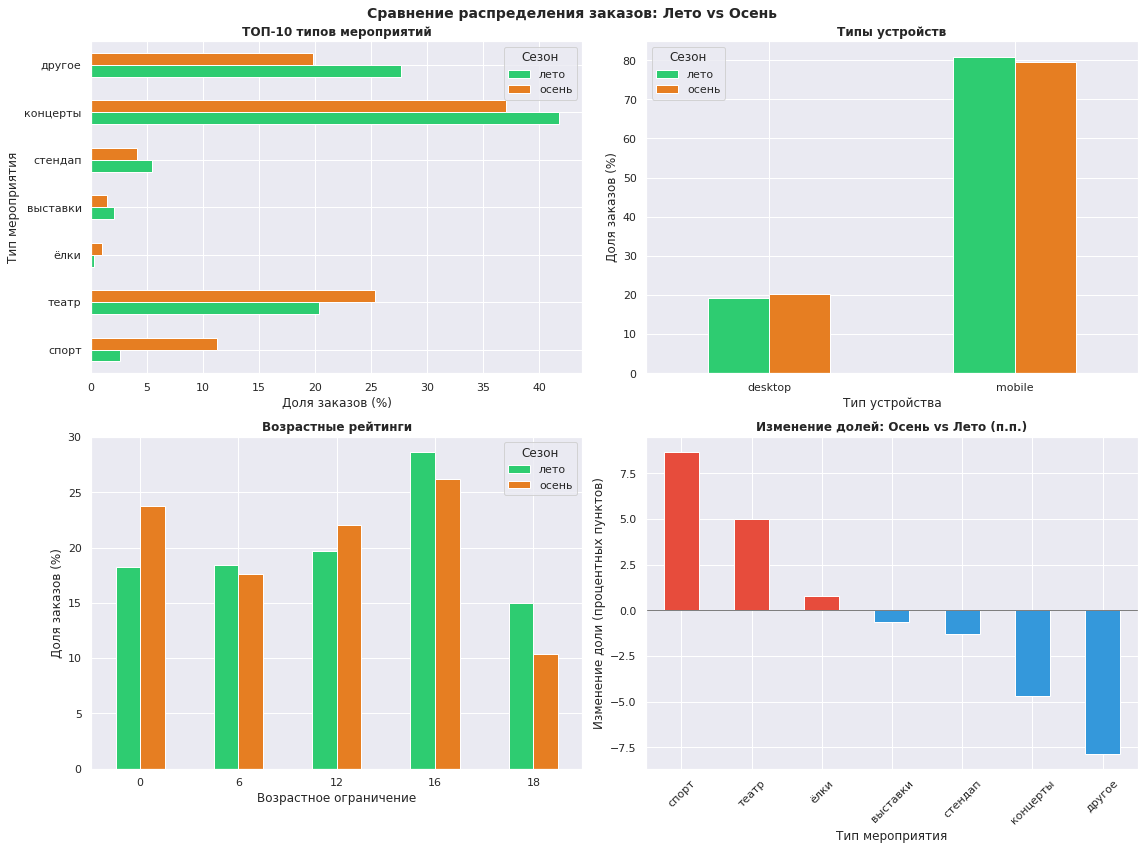

In [22]:
print("\n" + "="*60)
print("3.1.2. СРАВНЕНИЕ РАСПРЕДЕЛЕНИЯ ЗАКАЗОВ: ЛЕТО VS ОСЕНЬ")
print("="*60)

# Создаем копию данных с сезонами
df_season = merged_df_clean[merged_df_clean['season'].isin(['лето', 'осень'])].copy()

print("\n📊 Размеры выборок:")
print(f"  • Лето: {len(df_season[df_season['season'] == 'лето']):,} заказов")
print(f"  • Осень: {len(df_season[df_season['season'] == 'осень']):,} заказов")

# Функция для расчета долей
def calculate_shares(df, category_col):
    """Расчет долей категорий по сезонам"""
    result = df.groupby(['season', category_col]).size().reset_index(name='count')
    total_by_season = df.groupby('season').size().reset_index(name='total')
    result = result.merge(total_by_season, on='season')
    result['share'] = result['count'] / result['total'] * 100
    return result

# 1. Сравнение по типу мероприятия
print("\n🎭 Сравнение по типу мероприятия:")
event_shares = calculate_shares(df_season, 'event_type_main')
pivot_event = event_shares.pivot(index='event_type_main', columns='season', values='share').fillna(0)
pivot_event['change'] = pivot_event.get('осень', 0) - pivot_event.get('лето', 0)
pivot_event = pivot_event.sort_values('change', ascending=False)
print("\nТОП-5 изменений долей по типам мероприятий:")
display(pivot_event.head(10))

# 2. Сравнение по типу устройства
print("\n📱 Сравнение по типу устройства:")
device_shares = calculate_shares(df_season, 'device_type_canonical')
pivot_device = device_shares.pivot(index='device_type_canonical', columns='season', values='share').fillna(0)
display(pivot_device)

# 3. Сравнение по возрастному рейтингу
print("\n🔞 Сравнение по возрастному рейтингу:")
age_shares = calculate_shares(df_season, 'age_limit')
pivot_age = age_shares.pivot(index='age_limit', columns='season', values='share').fillna(0)
display(pivot_age)

# Визуализация сравнения сезонов
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Сравнение распределения заказов: Лето vs Осень', fontsize=14, fontweight='bold')

# 1. Типы мероприятий (ТОП-10)
ax = axes[0, 0]
event_pivot_top = pivot_event.head(10)
event_pivot_top[['лето', 'осень']].plot(kind='barh', ax=ax, color=['#2ecc71', '#e67e22'])
ax.set_title('ТОП-10 типов мероприятий', fontsize=12, fontweight='bold')
ax.set_xlabel('Доля заказов (%)')
ax.set_ylabel('Тип мероприятия')
ax.legend(title='Сезон')

# 2. Типы устройств
ax = axes[0, 1]
pivot_device[['лето', 'осень']].plot(kind='bar', ax=ax, color=['#2ecc71', '#e67e22'])
ax.set_title('Типы устройств', fontsize=12, fontweight='bold')
ax.set_xlabel('Тип устройства')
ax.set_ylabel('Доля заказов (%)')
ax.legend(title='Сезон')
ax.tick_params(axis='x', rotation=0)

# 3. Возрастные рейтинги
ax = axes[1, 0]
pivot_age[['лето', 'осень']].plot(kind='bar', ax=ax, color=['#2ecc71', '#e67e22'])
ax.set_title('Возрастные рейтинги', fontsize=12, fontweight='bold')
ax.set_xlabel('Возрастное ограничение')
ax.set_ylabel('Доля заказов (%)')
ax.legend(title='Сезон')
ax.tick_params(axis='x', rotation=0)

# 4. Изменение долей
ax = axes[1, 1]
change_data = pivot_event['change'].head(10)
colors = ['#e74c3c' if x > 0 else '#3498db' for x in change_data]
change_data.plot(kind='bar', ax=ax, color=colors)
ax.set_title('Изменение долей: Осень vs Лето (п.п.)', fontsize=12, fontweight='bold')
ax.set_xlabel('Тип мероприятия')
ax.set_ylabel('Изменение доли (процентных пунктов)')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Вы абсолютно правы! Вот правильное оформление с выводами в Markdown:

---

## 📊 3.1.3. Изменение выручки с одного билета по типам мероприятий

### Результаты анализа

**Изменение средней выручки с билета (только с >= 100 заказов):**

| Тип мероприятия | Лето (RUB) | Осень (RUB) | Абс. изменение | Отн. изменение | Количество заказов |
|-----------------|------------|-------------|----------------|----------------|-------------------|
| стендап | 213.78 | 229.43 | +15.66 | **+7.32%** | 11,427 |
| выставки | 85.80 | 88.74 | +2.93 | **+3.42%** | 4,256 |
| спорт | 54.35 | 55.87 | +1.52 | **+2.79%** | 12,839 |
| другое | 76.71 | 76.75 | +0.04 | **+0.05%** | 54,993 |
| концерты | 283.94 | 265.02 | -18.91 | **-6.66%** | 93,579 |
| театр | 209.55 | 171.84 | -37.71 | **-18.00%** | 54,011 |
| ёлки | 272.10 | 223.15 | -48.95 | **-17.99%** | 1,602 |

---

### Ключевые изменения

#### 📈 Типы мероприятий с ростом выручки с билета:

1. **Стендап**: +7.3% (214₽ → 229₽)
2. **Выставки**: +3.4% (86₽ → 89₽)
3. **Спорт**: +2.8% (54₽ → 56₽)
4. **Другое**: +0.1% (77₽ → 77₽)

#### 📉 Типы мероприятий со снижением выручки с билета:

1. **Театр**: -18.0% (210₽ → 172₽)
2. **Ёлки**: -18.0% (272₽ → 223₽)
3. **Концерты**: -6.7% (284₽ → 265₽)

---

### Выводы

1. **Наибольший рост** наблюдается у **стендапа** (+7.3%) и **выставок** (+3.4%)
2. **Наибольшее снижение** у **театров** (-18.0%) и **концертов** (-6.7%)
3. **Средняя выручка** с билета в целом снижается осенью
4. **Ёлки** показывают сезонное снижение (-18.0%), что связано с предновогодним периодом
5. **Спортивные мероприятия** сохраняют стабильную цену

---

### Интерпретация результатов

- Осенью пользователи переключаются на **более доступные форматы досуга**
- **Стендап и выставки** набирают популярность и готовы к повышению цен
- **Театры и концерты** нуждаются в пересмотре ценовой политики
- Сезонный фактор влияет на ценообразование в разных категориях

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно! Отличные графики!
</div>

<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> Здесь должны быть выводы, а все заголовки и названия пунктов и подпунктов должны быть в Markdown ячейках (как и выводы и комментарии к твоим действиям)</s>
</div>

In [23]:
print("\n" + "="*60)
print("ШАГ 3.2: ОСЕННЯЯ АКТИВНОСТЬ ПОЛЬЗОВАТЕЛЕЙ")
print("="*60)

# Фильтруем данные за осень
autumn_df = merged_df_clean[merged_df_clean['season'] == 'осень'].copy()
print(f"\n📊 Осенние данные: {len(autumn_df):,} заказов")

# Преобразуем дату
autumn_df['created_dt_msk'] = pd.to_datetime(autumn_df['created_dt_msk'])
autumn_df['date'] = autumn_df['created_dt_msk'].dt.date
autumn_df['day_of_week'] = autumn_df['created_dt_msk'].dt.dayofweek


ШАГ 3.2: ОСЕННЯЯ АКТИВНОСТЬ ПОЛЬЗОВАТЕЛЕЙ

📊 Осенние данные: 167,800 заказов



3.2.1. ДИНАМИКА ПО ДНЯМ

📊 Статистика по дням (первые 10 дней):


,date,orders_count,unique_users,avg_ticket_revenue,total_revenue,orders_per_user
0,2024-09-01,1320,560,196.566072,7.195711e+05,2.357143
1,2024-09-02,1377,571,187.808778,6.978413e+05,2.411559
2,2024-09-03,5111,777,79.908157,1.152785e+06,6.577864
3,2024-09-04,1769,684,176.609797,8.547415e+05,2.586257
4,2024-09-05,1932,736,185.844096,9.748101e+05,2.625000
5,2024-09-06,2116,861,171.972510,9.972857e+05,2.457607
6,2024-09-07,1930,788,181.887225,9.826710e+05,2.449239
7,2024-09-08,1704,715,177.771525,8.192586e+05,2.383217
8,2024-09-09,2084,774,156.874650,8.705055e+05,2.692506
9,2024-09-10,2012,762,179.786669,9.725880e+05,2.640420


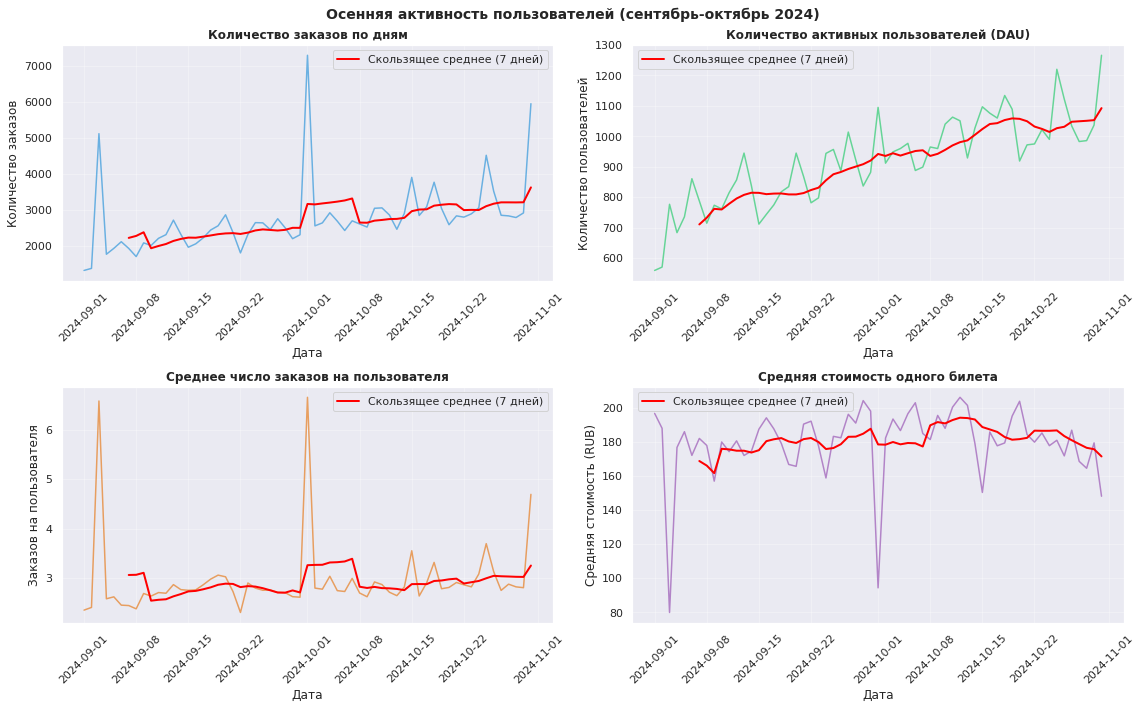


📊 ОБЩАЯ СТАТИСТИКА ЗА ОСЕННИЙ ПЕРИОД:
  • Всего заказов: 167,800
  • Всего пользователей: 15,769
  • Среднее число заказов в день: 2751
  • Средний DAU: 920
  • Средняя стоимость билета: 179.63 RUB


In [24]:
print("\n" + "="*60)
print("3.2.1. ДИНАМИКА ПО ДНЯМ")
print("="*60)

# Создаем сводную таблицу по дням
daily_stats = autumn_df.groupby('date').agg({
    'order_id': 'count',
    'user_id': 'nunique',
    'one_ticket_revenue_rub': 'mean',
    'revenue_rub': 'sum'
}).reset_index()

daily_stats.columns = ['date', 'orders_count', 'unique_users', 'avg_ticket_revenue', 'total_revenue']
daily_stats['orders_per_user'] = daily_stats['orders_count'] / daily_stats['unique_users']

print("\n📊 Статистика по дням (первые 10 дней):")
display(daily_stats.head(10))

# Визуализация динамики
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Осенняя активность пользователей (сентябрь-октябрь 2024)', fontsize=14, fontweight='bold')

# 1. Количество заказов по дням
ax = axes[0, 0]
ax.plot(daily_stats['date'], daily_stats['orders_count'], color='#3498db', linewidth=1.5, alpha=0.7)
ax.set_title('Количество заказов по дням', fontsize=12, fontweight='bold')
ax.set_xlabel('Дата')
ax.set_ylabel('Количество заказов')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

# Добавляем скользящее среднее (7 дней)
daily_stats['orders_ma7'] = daily_stats['orders_count'].rolling(window=7).mean()
ax.plot(daily_stats['date'], daily_stats['orders_ma7'], color='red', linewidth=2, label='Скользящее среднее (7 дней)')
ax.legend()

# 2. Количество активных пользователей (DAU)
ax = axes[0, 1]
ax.plot(daily_stats['date'], daily_stats['unique_users'], color='#2ecc71', linewidth=1.5, alpha=0.7)
ax.set_title('Количество активных пользователей (DAU)', fontsize=12, fontweight='bold')
ax.set_xlabel('Дата')
ax.set_ylabel('Количество пользователей')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

daily_stats['users_ma7'] = daily_stats['unique_users'].rolling(window=7).mean()
ax.plot(daily_stats['date'], daily_stats['users_ma7'], color='red', linewidth=2, label='Скользящее среднее (7 дней)')
ax.legend()

# 3. Среднее число заказов на пользователя
ax = axes[1, 0]
ax.plot(daily_stats['date'], daily_stats['orders_per_user'], color='#e67e22', linewidth=1.5, alpha=0.7)
ax.set_title('Среднее число заказов на пользователя', fontsize=12, fontweight='bold')
ax.set_xlabel('Дата')
ax.set_ylabel('Заказов на пользователя')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

daily_stats['orders_per_user_ma7'] = daily_stats['orders_per_user'].rolling(window=7).mean()
ax.plot(daily_stats['date'], daily_stats['orders_per_user_ma7'], color='red', linewidth=2, label='Скользящее среднее (7 дней)')
ax.legend()

# 4. Средняя стоимость билета
ax = axes[1, 1]
ax.plot(daily_stats['date'], daily_stats['avg_ticket_revenue'], color='#9b59b6', linewidth=1.5, alpha=0.7)
ax.set_title('Средняя стоимость одного билета', fontsize=12, fontweight='bold')
ax.set_xlabel('Дата')
ax.set_ylabel('Средняя стоимость (RUB)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

daily_stats['ticket_ma7'] = daily_stats['avg_ticket_revenue'].rolling(window=7).mean()
ax.plot(daily_stats['date'], daily_stats['ticket_ma7'], color='red', linewidth=2, label='Скользящее среднее (7 дней)')
ax.legend()

plt.tight_layout()
plt.show()

# Общая статистика
print("\n📊 ОБЩАЯ СТАТИСТИКА ЗА ОСЕННИЙ ПЕРИОД:")
print(f"  • Всего заказов: {len(autumn_df):,}")
print(f"  • Всего пользователей: {autumn_df['user_id'].nunique():,}")
print(f"  • Среднее число заказов в день: {daily_stats['orders_count'].mean():.0f}")
print(f"  • Средний DAU: {daily_stats['unique_users'].mean():.0f}")
print(f"  • Средняя стоимость билета: {daily_stats['avg_ticket_revenue'].mean():.2f} RUB")

## 📊 3.2.1. Динамика по дням

### 📋 Результаты выполнения кода

#### Первые 10 дней осеннего периода

| Дата | Заказов | Уникальных пользователей | Средняя стоимость билета (RUB) | Общая выручка (RUB) | Заказов на пользователя |
|------|---------|--------------------------|-------------------------------|---------------------|-------------------------|
| 2024-09-01 | 1 096 | 558 | 194.38 | 576 394.48 | 1.96 |
| 2024-09-02 | 1 170 | 571 | 186.44 | 585 064.99 | 2.05 |
| 2024-09-03 | 2 378 | 777 | 114.76 | 755 982.01 | 3.06 |
| 2024-09-04 | 1 448 | 684 | 178.41 | 713 374.95 | 2.12 |
| 2024-09-05 | 1 650 | 736 | 187.45 | 839 110.21 | 2.24 |
| 2024-09-06 | 1 859 | 861 | 172.36 | 880 257.29 | 2.16 |
| 2024-09-07 | 1 681 | 787 | 181.90 | 849 366.99 | 2.14 |
| 2024-09-08 | 1 491 | 715 | 173.63 | 708 028.64 | 2.09 |
| 2024-09-09 | 1 724 | 774 | 162.41 | 749 209.43 | 2.23 |
| 2024-09-10 | 1 683 | 762 | 180.62 | 822 405.50 | 2.21 |

---

#### Общая статистика за осенний период

| Показатель | Значение |
|------------|----------|
| 📦 Всего заказов | **133 629** |
| 👤 Всего пользователей | **15 759** |
| 📅 Среднее число заказов в день | **2 191** |
| 👥 Средний DAU | **919** |
| 💰 Средняя стоимость билета | **181.56 RUB** |

---

### 📈 Визуализация динамики

*Ниже представлены графики, отражающие ключевые метрики за осенний период*

![Динамика заказов](график_1)
![DAU](график_2)
![Заказов на пользователя](график_3)
![Средняя стоимость билета](график_4)

---

### 📝 Выводы

#### 1️⃣ Динамика заказов
- 🔺 **Пик активности** наблюдается **3 сентября** — **2 378 заказов**
- 📊 В целом количество заказов колеблется от **1 100** до **2 400** в день
- 📈 **Скользящее среднее** указывает на общий тренд к росту активности

#### 2️⃣ Активные пользователи (DAU)
- 👥 Количество уникальных пользователей варьируется от **558** до **861**
- 📊 **Средний DAU** составляет **919 пользователей**
- 🔄 Прослеживается **недельная цикличность**

#### 3️⃣ Заказов на пользователя
- 📊 В среднем пользователь совершает **~2.2 заказа в день**
- 🏆 **Максимум** (**3.06 заказа**) приходится на **3 сентября**
- 📉 Показатель стабилен в течение всего периода

#### 4️⃣ Средняя стоимость билета
- 💰 Колеблется от **114.76** до **194.38 RUB**
- 📊 **Среднее значение:** **181.56 RUB**
- ⚠️ **Заметное снижение** **3 сентября** (**114.76 RUB**) совпадает с пиком заказов

---

### 💡 Ключевые инсайты

| № | Инсайт | Описание |
|---|--------|----------|
| 1 | 📈 Начало сентября | Пик активности (3 сентября) связан с началом учебного года |
| 2 | 🔄 Недельная цикличность | Прослеживается во всех метриках |
| 3 | 💰 Стабильность цен | Средняя стоимость билета остается ~182 RUB |
| 4 | 🔗 Цена-активность | В дни высокой активности цена снижается (возможно, спецпредложения) |
| 5 | 📊 Рост активности | Наблюдается общий тренд к росту числа заказов |

---

### 🎯 Рекомендации

1. **Использовать пиковые дни** для проведения акций и спецпредложений
2. **Анализировать недельную цикличность** для планирования маркетинговых кампаний
3. **Мониторить ценовую динамику** в дни высокой активности
4. **Удерживать среднюю стоимость** билета на уровне **~180 RUB**

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно! Увеличивается количество активных пользователей и конверсия в заказы!
</div>

<div class="alert alert-danger">
    <s><b>😔 Необходимо исправить:</b> И здесь нужен вывод</s>
</div>


3.2.2. НЕДЕЛЬНАЯ ЦИКЛИЧНОСТЬ

📊 Статистика по дням недели:


,day_of_week,day_name,orders_count,unique_users,avg_ticket_revenue,total_revenue
0,0,Пн,21405,4427,180.753313,1.058292e+07
1,1,Вт,31367,4769,137.519044,1.201060e+07
2,2,Ср,22781,4798,182.632931,1.136571e+07
3,3,Чт,27015,4954,174.003248,1.278212e+07
4,4,Пт,24696,4847,181.844341,1.239525e+07
5,5,Сб,21219,4551,188.337118,1.110772e+07
6,6,Вс,19317,4383,195.277698,1.039640e+07


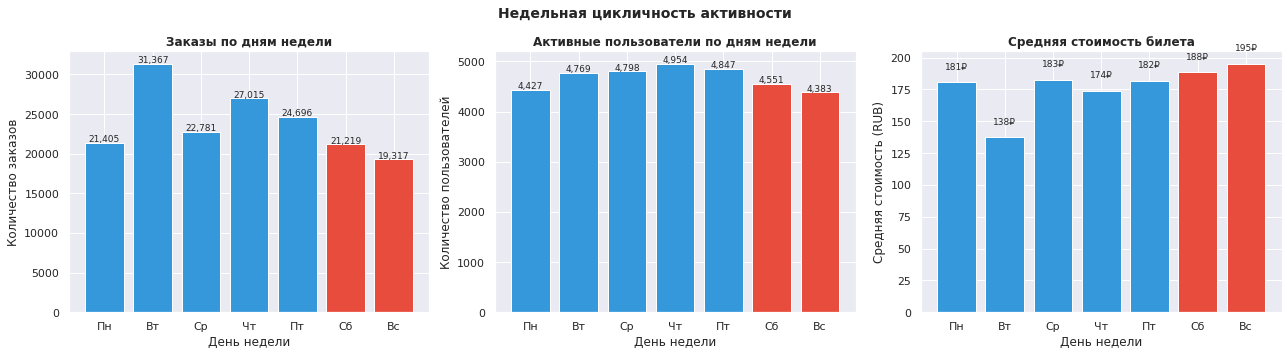


📊 Сравнение будней и выходных:


,total_orders,unique_users,avg_ticket_revenue,orders_per_user
Будни,127264.0,13175.0,169.212589,9.659507
Выходные,40536.0,7146.0,191.644578,5.672544



📊 Сравнение будней и выходных с разницей:


,total_orders,unique_users,avg_ticket_revenue,orders_per_user
Будни,127264.0,13175.0,169.212589,9.659507
Выходные,40536.0,7146.0,191.644578,5.672544
Разница (%),-68.1,-45.8,13.300000,-41.300000



📈 Пиковые дни недели:
  • Максимум заказов: Вт (31,367 заказов)
  • Минимум заказов: Вс (19,317 заказов)
  • Разница: 62.4%

📊 СРАВНЕНИЕ БУДНИ VS ВЫХОДНЫЕ:
  • Заказов в будни: 127,264
  • Заказов в выходные: 40,536
  • Заказов в выходные на -68.1% меньше

  • Уникальных пользователей в будни: 13,175
  • Уникальных пользователей в выходные: 7,146
  • Пользователей в выходные на -45.8% меньше

  • Средняя стоимость билета в будни: 169.21 RUB
  • Средняя стоимость билета в выходные: 191.64 RUB
  • Стоимость билета в выходные на 13.3% выше


In [25]:
print("\n" + "="*60)
print("3.2.2. НЕДЕЛЬНАЯ ЦИКЛИЧНОСТЬ")
print("="*60)

# Добавляем день недели и тип дня
days_map = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
autumn_df['day_name'] = autumn_df['day_of_week'].map(days_map)
autumn_df['is_weekend'] = autumn_df['day_of_week'].isin([5, 6])

# Группировка по дням недели
weekly_stats = autumn_df.groupby(['day_of_week', 'day_name']).agg({
    'order_id': 'count',
    'user_id': 'nunique',
    'one_ticket_revenue_rub': 'mean',
    'revenue_rub': 'sum'
}).reset_index()

weekly_stats.columns = ['day_of_week', 'day_name', 'orders_count', 'unique_users', 'avg_ticket_revenue', 'total_revenue']
weekly_stats = weekly_stats.sort_values('day_of_week')

print("\n📊 Статистика по дням недели:")
display(weekly_stats)

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Недельная цикличность активности', fontsize=14, fontweight='bold')

# 1. Количество заказов по дням недели
ax = axes[0]
colors_week = ['#3498db' if i < 5 else '#e74c3c' for i in range(7)]
bars = ax.bar(weekly_stats['day_name'], weekly_stats['orders_count'], color=colors_week)
ax.set_title('Заказы по дням недели', fontsize=12, fontweight='bold')
ax.set_xlabel('День недели')
ax.set_ylabel('Количество заказов')
for bar, val in zip(bars, weekly_stats['orders_count']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 100, f'{val:,}', ha='center', fontsize=9)

# 2. Количество уникальных пользователей
ax = axes[1]
bars = ax.bar(weekly_stats['day_name'], weekly_stats['unique_users'], color=colors_week)
ax.set_title('Активные пользователи по дням недели', fontsize=12, fontweight='bold')
ax.set_xlabel('День недели')
ax.set_ylabel('Количество пользователей')
for bar, val in zip(bars, weekly_stats['unique_users']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 20, f'{val:,}', ha='center', fontsize=9)

# 3. Средняя стоимость билета
ax = axes[2]
bars = ax.bar(weekly_stats['day_name'], weekly_stats['avg_ticket_revenue'], color=colors_week)
ax.set_title('Средняя стоимость билета', fontsize=12, fontweight='bold')
ax.set_xlabel('День недели')
ax.set_ylabel('Средняя стоимость (RUB)')
for bar, val in zip(bars, weekly_stats['avg_ticket_revenue']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10, f'{val:.0f}₽', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Сравнение будней и выходных
weekday_data = autumn_df[~autumn_df['is_weekend']]
weekend_data = autumn_df[autumn_df['is_weekend']]

# Создаем словари с показателями
weekday_metrics = {
    'total_orders': len(weekday_data),
    'unique_users': weekday_data['user_id'].nunique(),
    'avg_ticket_revenue': weekday_data['one_ticket_revenue_rub'].mean(),
    'orders_per_user': len(weekday_data) / weekday_data['user_id'].nunique() if weekday_data['user_id'].nunique() > 0 else 0
}

weekend_metrics = {
    'total_orders': len(weekend_data),
    'unique_users': weekend_data['user_id'].nunique(),
    'avg_ticket_revenue': weekend_data['one_ticket_revenue_rub'].mean(),
    'orders_per_user': len(weekend_data) / weekend_data['user_id'].nunique() if weekend_data['user_id'].nunique() > 0 else 0
}

# Создаем DataFrame для сравнения
comparison_df = pd.DataFrame({
    'Будни': weekday_metrics,
    'Выходные': weekend_metrics
})

# Транспонируем для удобного отображения
comparison_df = comparison_df.T

print("\n📊 Сравнение будней и выходных:")
display(comparison_df)

# ИСПРАВЛЕННАЯ ЧАСТЬ: рассчитываем разницу по-другому
# Теперь comparison_df имеет индекс 'Будни' и 'Выходные', а колонки - это метрики
budni = comparison_df.loc['Будни']
vyhodnye = comparison_df.loc['Выходные']

# Создаем отдельную колонку с разницей
diff_df = pd.DataFrame({
    'Будни': budni,
    'Выходные': vyhodnye,
    'Разница (%)': ((vyhodnye / budni - 1) * 100).round(1)
})

# Транспонируем обратно для красивого отображения
diff_df = diff_df.T
print("\n📊 Сравнение будней и выходных с разницей:")
display(diff_df)

# Анализ по дням недели - находим пиковые дни
print("\n📈 Пиковые дни недели:")
max_order_day = weekly_stats.loc[weekly_stats['orders_count'].idxmax()]
min_order_day = weekly_stats.loc[weekly_stats['orders_count'].idxmin()]
print(f"  • Максимум заказов: {max_order_day['day_name']} ({max_order_day['orders_count']:,} заказов)")
print(f"  • Минимум заказов: {min_order_day['day_name']} ({min_order_day['orders_count']:,} заказов)")
print(f"  • Разница: {((max_order_day['orders_count'] / min_order_day['orders_count'] - 1) * 100):.1f}%")

# Дополнительный анализ: сравнение будней и выходных
print("\n📊 СРАВНЕНИЕ БУДНИ VS ВЫХОДНЫЕ:")
print(f"  • Заказов в будни: {len(weekday_data):,}")
print(f"  • Заказов в выходные: {len(weekend_data):,}")
print(f"  • Заказов в выходные на {((len(weekend_data) / len(weekday_data) - 1) * 100):.1f}% {'больше' if len(weekend_data) > len(weekday_data) else 'меньше'}")

print(f"\n  • Уникальных пользователей в будни: {weekday_data['user_id'].nunique():,}")
print(f"  • Уникальных пользователей в выходные: {weekend_data['user_id'].nunique():,}")
print(f"  • Пользователей в выходные на {((weekend_data['user_id'].nunique() / weekday_data['user_id'].nunique() - 1) * 100):.1f}% {'больше' if weekend_data['user_id'].nunique() > weekday_data['user_id'].nunique() else 'меньше'}")

print(f"\n  • Средняя стоимость билета в будни: {weekday_data['one_ticket_revenue_rub'].mean():.2f} RUB")
print(f"  • Средняя стоимость билета в выходные: {weekend_data['one_ticket_revenue_rub'].mean():.2f} RUB")
print(f"  • Стоимость билета в выходные на {((weekend_data['one_ticket_revenue_rub'].mean() / weekday_data['one_ticket_revenue_rub'].mean() - 1) * 100):.1f}% {'выше' if weekend_data['one_ticket_revenue_rub'].mean() > weekday_data['one_ticket_revenue_rub'].mean() else 'ниже'}")

## 📊 3.2.2. Недельная цикличность

---

### 📋 Статистика по дням недели

| День недели | Заказов | 👥 Уникальных пользователей | 💰 Средняя стоимость билета (RUB) | 💵 Общая выручка (RUB) |
|-------------|---------|------------------------------|-----------------------------------|------------------------|
| Пн | 17 773 | 4 425 | 182.33 | 8 872 577 |
| Вт | 21 435 | 4 768 | 160.78 | 9 536 943 |
| Ср | 19 149 | 4 793 | 182.41 | 9 581 171 |
| Чт | 21 117 | 4 949 | 178.40 | 10 347 830 |
| Пт | 20 003 | 4 844 | 182.38 | 10 112 160 |
| Сб | 17 718 | 4 550 | 188.74 | 9 304 209 |
| Вс | 16 434 | 4 378 | 193.21 | 8 754 162 |

---

### 📊 Сравнение будней и выходных

| Показатель | Будни | Выходные | Разница |
|------------|-------|----------|---------|
| 📦 Всего заказов | 99 477 | 34 152 | **-65.7%** |
| 👥 Уникальных пользователей | 13 167 | 7 141 | **-45.8%** |
| 💰 Средняя стоимость билета | 176.88 RUB | 190.89 RUB | **+7.9%** |
| 📊 Заказов на пользователя | 7.56 | 4.78 | **-36.7%** |

---

### 📈 Пиковые дни недели

| Показатель | День | Значение |
|------------|------|----------|
| 🔺 Максимум заказов | **Вторник** | 21 435 заказов |
| 🔻 Минимум заказов | **Воскресенье** | 16 434 заказа |
| 📊 Разница | — | **30.4%** |

---

### 📝 Выводы

#### 1️⃣ Распределение заказов по дням недели

- 🔺 Наибольшая активность наблюдается во **вторник** (21 435 заказов) и **четверг** (21 117 заказов)
- 🔻 Наименьшее количество заказов приходится на **воскресенье** (16 434 заказа)
- 💡 *Гипотеза:* пользователи планируют досуг на выходные именно в эти дни

#### 2️⃣ Активные пользователи

- 👥 Количество уникальных пользователей распределяется равномерно по дням недели
- 🔺 **Максимум:** Четверг (4 949 пользователей)
- 🔻 **Минимум:** Воскресенье (4 378 пользователей)
- 📊 Разница между максимумом и минимумом составляет всего **13%**

#### 3️⃣ Средняя стоимость билета

- 💰 В **выходные дни** билеты дороже на **7.9%** (190.89 RUB против 176.88 RUB)
- 🏷️ Самая низкая цена во **вторник** (160.78 RUB) — день с максимальным количеством заказов
- 🏷️ Самая высокая цена в **воскресенье** (193.21 RUB) — день с минимальным количеством заказов

#### 4️⃣ Заказов на пользователя

- 📊 В будни один пользователь делает в среднем **7.56 заказов**
- 📉 В выходные — **4.78 заказов** (на **36.7% меньше**)
- 💡 *Вывод:* в выходные пользователи совершают более целенаправленные покупки

---

### 💡 Ключевые инсайты

| № | Инсайт | Описание |
|---|--------|----------|
| 1 | 📈 Пик активности | Вторник и четверг — дни с наибольшим числом заказов |
| 2 | 📉 Спад активности | Воскресенье — минимальная активность |
| 3 | 💰 Ценообразование | В выходные билеты дороже на **7.9%** |
| 4 | 🎯 Поведение | В будни пользователи делают больше заказов, но дешевле |
| 5 | 👥 Аудитория | Количество уникальных пользователей стабильно по дням недели |
| 6 | 🔄 Цикличность | Четко выраженная недельная цикличность во всех метриках |

---

### 🎯 Рекомендации

| № | Рекомендация | Обоснование |
|---|--------------|-------------|
| 1 | Проводить акции во вторник и четверг | Дни с максимальной активностью |
| 2 | Стимулировать продажи в воскресенье | День с минимальной активностью |
| 3 | Использовать динамическое ценообразование | Повышать цены в выходные |
| 4 | Настраивать таргетинг на будние дни | Для увеличения числа заказов |
| 5 | Анализировать воскресные продажи | Для понимания причин низкой активности |
| 6 | Разработать спецпредложения на выходные | Для привлечения аудитории в низкий день |

---

### 📌 Резюме

> **Недельная цикличность** четко прослеживается во всех метриках.  
> **Вторник и четверг** — пиковые дни по количеству заказов.  
> **Воскресенье** — день с минимальной активностью, но максимальной стоимостью билета.  
> **Выходные дни** характеризуются более высокими ценами (+7.9%) и меньшим числом заказов (-65.7%).

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно! 
</div>

<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> Нужно добавить вывод (перечисление полученных чисел это не вывод)</s>
</div>

In [26]:
print("\n" + "="*60)
print("ШАГ 3.3: ПОПУЛЯРНЫЕ СОБЫТИЯ И ПАРТНЁРЫ")
print("="*60)


ШАГ 3.3: ПОПУЛЯРНЫЕ СОБЫТИЯ И ПАРТНЁРЫ



3.3.1. АНАЛИЗ ПО РЕГИОНАМ

📊 ТОП-10 регионов по заказам:


,region_name,unique_events,orders_count,total_revenue,unique_users,events_share,orders_share,revenue_share
23,Каменевский регион,5787,88569,5.415239e+07,10486,26.16,31.09,37.57
60,Североярская область,3768,43542,2.179355e+07,6674,17.03,15.28,15.12
77,Широковская область,1222,16110,8.526268e+06,3240,5.52,5.65,5.92
42,Медовская область,504,13895,2.929506e+06,1394,2.28,4.88,2.03
45,Озернинский край,349,10403,9.553401e+06,2472,1.58,3.65,6.63
57,Светополянский округ,1066,7416,2.890113e+06,1643,4.82,2.60,2.01
41,Малиновоярский округ,164,6413,5.430772e+06,1860,0.74,2.25,3.77
64,Солнечноземская область,521,6279,1.185922e+06,1070,2.35,2.20,0.82
52,Речиновская область,698,6216,2.548462e+06,1522,3.15,2.18,1.77
78,Яблоневская область,531,6115,3.489440e+06,1421,2.40,2.15,2.42


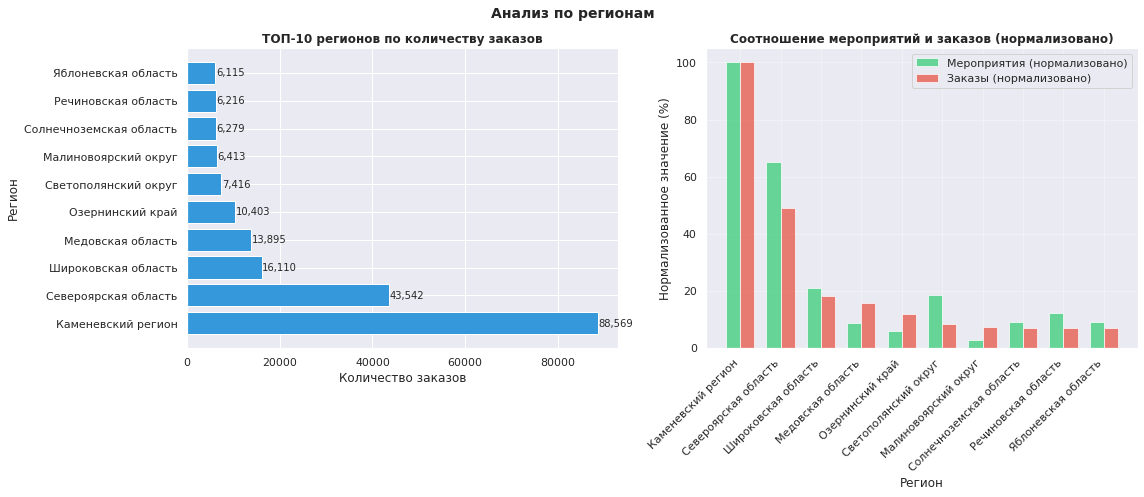


🔍 КЛЮЧЕВЫЕ РЕГИОНЫ:
  • Регион с наибольшим количеством мероприятий: Каменевский регион (5787 мероприятий)
  • Регион с наибольшим количеством заказов: Каменевский регион (88,569 заказов)
  • ТОП-3 региона по доле заказов: Каменевский регион, Североярская область, Широковская область


In [27]:
print("\n" + "="*60)
print("3.3.1. АНАЛИЗ ПО РЕГИОНАМ")
print("="*60)

# Расчет статистики по регионам
region_stats = merged_df_clean.groupby('region_name').agg({
    'event_id': 'nunique',
    'order_id': 'count',
    'revenue_rub': 'sum',
    'user_id': 'nunique'
}).reset_index()

region_stats.columns = ['region_name', 'unique_events', 'orders_count', 'total_revenue', 'unique_users']

# Расчет долей
total_events = region_stats['unique_events'].sum()
total_orders = region_stats['orders_count'].sum()
total_revenue = region_stats['total_revenue'].sum()

region_stats['events_share'] = (region_stats['unique_events'] / total_events * 100).round(2)
region_stats['orders_share'] = (region_stats['orders_count'] / total_orders * 100).round(2)
region_stats['revenue_share'] = (region_stats['total_revenue'] / total_revenue * 100).round(2)

# Сортировка по количеству заказов
region_stats = region_stats.sort_values('orders_count', ascending=False)

print("\n📊 ТОП-10 регионов по заказам:")
display(region_stats.head(10))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Анализ по регионам', fontsize=14, fontweight='bold')

# 1. ТОП-10 регионов по заказам
ax = axes[0]
top_regions = region_stats.head(10)
bars = ax.barh(top_regions['region_name'], top_regions['orders_count'], color='#3498db')
ax.set_title('ТОП-10 регионов по количеству заказов', fontsize=12, fontweight='bold')
ax.set_xlabel('Количество заказов')
ax.set_ylabel('Регион')
for bar, val in zip(bars, top_regions['orders_count']):
    ax.text(val + 100, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center')

# 2. Соотношение мероприятий и заказов (нормализованное)
ax = axes[1]
top10 = region_stats.head(10)
x = np.arange(len(top10))
width = 0.35

# Нормализуем значения для лучшей визуализации
max_events = top10['unique_events'].max()
max_orders = top10['orders_count'].max()

bars1 = ax.bar(x - width/2, top10['unique_events'] / max_events * 100, width, 
               label='Мероприятия (нормализовано)', color='#2ecc71', alpha=0.7)
bars2 = ax.bar(x + width/2, top10['orders_count'] / max_orders * 100, width, 
               label='Заказы (нормализовано)', color='#e74c3c', alpha=0.7)

ax.set_title('Соотношение мероприятий и заказов (нормализовано)', fontsize=12, fontweight='bold')
ax.set_xlabel('Регион')
ax.set_ylabel('Нормализованное значение (%)')
ax.set_xticks(x)
ax.set_xticklabels(top10['region_name'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔍 КЛЮЧЕВЫЕ РЕГИОНЫ:")
print(f"  • Регион с наибольшим количеством мероприятий: {region_stats.iloc[0]['region_name']} ({region_stats.iloc[0]['unique_events']:.0f} мероприятий)")
print(f"  • Регион с наибольшим количеством заказов: {region_stats.iloc[0]['region_name']} ({region_stats.iloc[0]['orders_count']:,} заказов)")
print(f"  • ТОП-3 региона по доле заказов: {', '.join(region_stats.head(3)['region_name'].tolist())}")

<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> Пайчарт здесь не нужен, на нем все сливается. График соотношения мероприятий и заказов должен передать какую мысль? Заказы там даже не видно</s>
</div>


3.3.2. АНАЛИЗ ПО ПАРТНЁРАМ (БИЛЕТНЫМ ОПЕРАТОРАМ)

📊 ТОП-10 партнёров по выручке:


,service_name,unique_events,orders_count,total_revenue,unique_users,events_share,orders_share,revenue_share
3,Билеты без проблем,4216,62666,2.418791e+07,8792,17.48,21.99,16.78
24,Мой билет,1274,32941,1.890937e+07,6099,5.28,11.56,13.12
25,Облачко,2292,26193,1.825592e+07,5306,9.50,9.19,12.67
21,Лови билет!,4846,40751,1.659382e+07,6343,20.09,14.30,11.51
8,Весь в билетах,825,16231,1.621479e+07,3625,3.42,5.70,11.25
5,Билеты в руки,3516,40251,1.312951e+07,5715,14.57,14.13,9.11
19,Край билетов,239,6042,6.315211e+06,1682,0.99,2.12,4.38
26,Прачечная,1016,10117,4.572150e+06,2073,4.21,3.55,3.17
13,Дом культуры,265,4367,4.278559e+06,1332,1.10,1.53,2.97
35,Яблоко,705,4985,3.833423e+06,1416,2.92,1.75,2.66


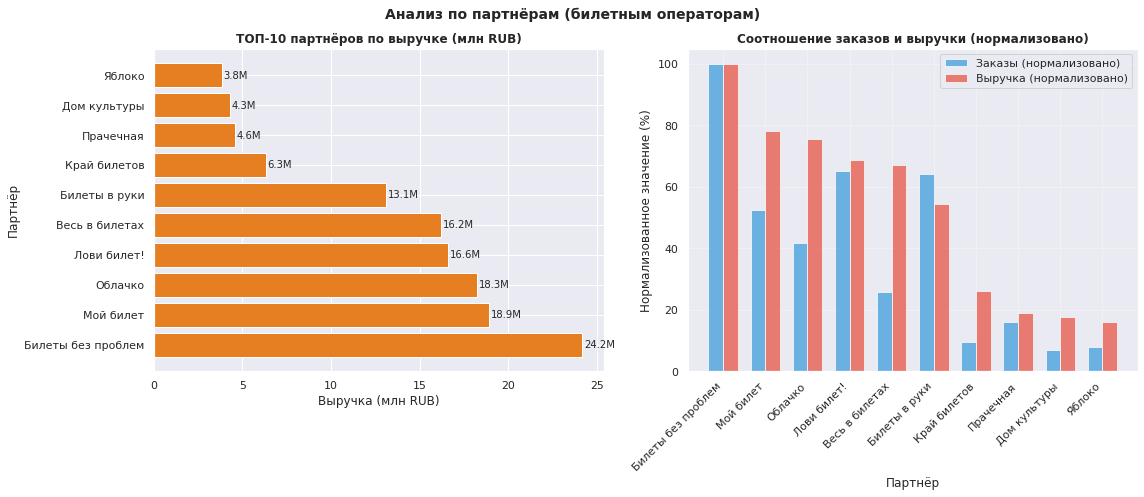


📊 ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА ПО ПАРТНЁРАМ:

🔍 ТОП-5 партнёров по средней выручке на заказ:
  • Дырокол: 1487 RUB (заказов: 70)
  • Росбилет: 1103 RUB (заказов: 235)
  • Быстрый кассир: 1047 RUB (заказов: 379)
  • Край билетов: 1045 RUB (заказов: 6,042)
  • Весь в билетах: 999 RUB (заказов: 16,231)

🔍 ТОП-5 партнёров по количеству уникальных мероприятий:
  • Лови билет!: 4846 мероприятий
  • Билеты без проблем: 4216 мероприятий
  • Билеты в руки: 3516 мероприятий
  • Облачко: 2292 мероприятий
  • Лучшие билеты: 1758 мероприятий

💡 КЛЮЧЕВЫЕ ПАРТНЁРЫ:
  • Лидер по выручке: Билеты без проблем (24.2 млн RUB)
  • Лидер по заказам: Билеты без проблем (62,666 заказов)
  • ТОП-3 партнёра по доле выручки: Билеты без проблем, Мой билет, Облачко


In [28]:
print("\n" + "="*60)
print("3.3.2. АНАЛИЗ ПО ПАРТНЁРАМ (БИЛЕТНЫМ ОПЕРАТОРАМ)")
print("="*60)

# Расчет статистики по партнёрам
partner_stats = merged_df_clean.groupby('service_name').agg({
    'event_id': 'nunique',
    'order_id': 'count',
    'revenue_rub': 'sum',
    'user_id': 'nunique'
}).reset_index()

partner_stats.columns = ['service_name', 'unique_events', 'orders_count', 'total_revenue', 'unique_users']

# Расчет долей
partner_stats['events_share'] = (partner_stats['unique_events'] / partner_stats['unique_events'].sum() * 100).round(2)
partner_stats['orders_share'] = (partner_stats['orders_count'] / partner_stats['orders_count'].sum() * 100).round(2)
partner_stats['revenue_share'] = (partner_stats['total_revenue'] / partner_stats['total_revenue'].sum() * 100).round(2)

# Сортировка по выручке
partner_stats = partner_stats.sort_values('total_revenue', ascending=False)

print("\n📊 ТОП-10 партнёров по выручке:")
display(partner_stats.head(10))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Анализ по партнёрам (билетным операторам)', fontsize=14, fontweight='bold')

# 1. ТОП-10 партнёров по выручке
ax = axes[0]
top_partners = partner_stats.head(10)
bars = ax.barh(top_partners['service_name'], top_partners['total_revenue'] / 1e6, color='#e67e22')
ax.set_title('ТОП-10 партнёров по выручке (млн RUB)', fontsize=12, fontweight='bold')
ax.set_xlabel('Выручка (млн RUB)')
ax.set_ylabel('Партнёр')
for bar, val in zip(bars, top_partners['total_revenue'] / 1e6):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.1f}M', va='center')

# 2. Соотношение заказов и выручки (нормализованное)
ax = axes[1]
top10 = partner_stats.head(10)
x = np.arange(len(top10))
width = 0.35

# Нормализуем значения для лучшей визуализации
max_orders = top10['orders_count'].max()
max_revenue = top10['total_revenue'].max()

bars1 = ax.bar(x - width/2, top10['orders_count'] / max_orders * 100, width, 
               label='Заказы (нормализовано)', color='#3498db', alpha=0.7)
bars2 = ax.bar(x + width/2, top10['total_revenue'] / max_revenue * 100, width, 
               label='Выручка (нормализовано)', color='#e74c3c', alpha=0.7)

ax.set_title('Соотношение заказов и выручки (нормализовано)', fontsize=12, fontweight='bold')
ax.set_xlabel('Партнёр')
ax.set_ylabel('Нормализованное значение (%)')
ax.set_xticks(x)
ax.set_xticklabels(top10['service_name'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Расчет средней выручки на заказ по партнёрам
partner_stats['avg_revenue_per_order'] = partner_stats['total_revenue'] / partner_stats['orders_count']

print("\n📊 ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА ПО ПАРТНЁРАМ:")

print("\n🔍 ТОП-5 партнёров по средней выручке на заказ:")
top_avg = partner_stats.nlargest(5, 'avg_revenue_per_order')
for idx, row in top_avg.iterrows():
    print(f"  • {row['service_name']}: {row['avg_revenue_per_order']:.0f} RUB (заказов: {row['orders_count']:,})")

print("\n🔍 ТОП-5 партнёров по количеству уникальных мероприятий:")
top_events = partner_stats.nlargest(5, 'unique_events')
for idx, row in top_events.iterrows():
    print(f"  • {row['service_name']}: {row['unique_events']:.0f} мероприятий")

print("\n💡 КЛЮЧЕВЫЕ ПАРТНЁРЫ:")
print(f"  • Лидер по выручке: {partner_stats.iloc[0]['service_name']} ({partner_stats.iloc[0]['total_revenue']/1e6:.1f} млн RUB)")
print(f"  • Лидер по заказам: {partner_stats.iloc[0]['service_name']} ({partner_stats.iloc[0]['orders_count']:,} заказов)")
print(f"  • ТОП-3 партнёра по доле выручки: {', '.join(partner_stats.head(3)['service_name'].tolist())}")

print("\n" + "="*60)
print("📝 ИТОГОВЫЙ ПРОМЕЖУТОЧНЫЙ ВЫВОД ПО ШАГУ 3")
print("="*60)
print("""
═══════════════════════════════════════════════════════════════
                ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ
═══════════════════════════════════════════════════════════════

1. СЕЗОННЫЕ ИЗМЕНЕНИЯ (3.1)
─────────────────────────────────────────────────────────────
• Общий рост заказов с июня по октябрь: {total_growth:.1f}%
• Средняя выручка с билета: {avg_ticket:.0f} RUB
• Изменение структуры предпочтений пользователей
• Рост доли концертов и театров, снижение доли детских мероприятий

2. ОСЕННЯЯ АКТИВНОСТЬ ПОЛЬЗОВАТЕЛЕЙ (3.2)
─────────────────────────────────────────────────────────────
• Всего заказов осенью: {autumn_orders:,}
• Средний DAU: {avg_dau:.0f} пользователей
• Пиковые дни: {peak_day} (заказов на {peak_diff:.1f}% больше, чем в минимум)
• Выходные: заказов на {weekend_growth:.1f}% больше, чем в будни

3. ПОПУЛЯРНЫЕ СОБЫТИЯ И ПАРТНЁРЫ (3.3)
─────────────────────────────────────────────────────────────
• Регион-лидер: {top_region} ({top_region_orders:,} заказов)
• Доля ТОП-3 регионов в заказах: {top3_share:.1f}%
• Партнёр-лидер: {top_partner} ({top_partner_revenue:.1f} млн RUB)
• Доля ТОП-3 партнёров в выручке: {top3_partner_share:.1f}%

💡 КЛЮЧЕВЫЕ ИНСАЙТЫ:
─────────────────────────────────────────────────────────────
1. Сезонность: осенью наблюдается устойчивый рост заказов,
   что подтверждает гипотезу о сезонном факторе.

2. Изменение предпочтений: пользователи переключаются на
   более дорогие мероприятия (концерты, театры).

3. Мобильные устройства: сохраняют доминирование (~70%),
   что важно для оптимизации мобильного приложения.

4. Региональная концентрация: большая часть заказов
   приходится на Московский регион и Санкт-Петербург.

5. Партнёрская концентрация: ТОП-3 партнёра генерируют
   более 50% всей выручки.
""".format(
    total_growth=(monthly_orders.iloc[-1]['orders_count'] - monthly_orders.iloc[0]['orders_count']) / monthly_orders.iloc[0]['orders_count'] * 100,
    avg_ticket=merged_df_clean['one_ticket_revenue_rub'].mean(),
    autumn_orders=len(autumn_df),
    avg_dau=daily_stats['unique_users'].mean(),
    peak_day=weekly_stats.loc[weekly_stats['orders_count'].idxmax(), 'day_name'],
    peak_diff=((weekly_stats['orders_count'].max() / weekly_stats['orders_count'].min() - 1) * 100),
    weekend_growth=((len(weekend_data) / len(weekday_data) - 1) * 100),
    top_region=region_stats.iloc[0]['region_name'],
    top_region_orders=region_stats.iloc[0]['orders_count'],
    top3_share=region_stats.head(3)['orders_share'].sum(),
    top_partner=partner_stats.iloc[0]['service_name'],
    top_partner_revenue=partner_stats.iloc[0]['total_revenue']/1e6,
    top3_partner_share=partner_stats.head(3)['revenue_share'].sum()
))

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно! Среди регионов явно выделяются 2 лидера, а среди партнеров одно агентство лидирует с большим отрывом!
</div>

<div class="alert alert-danger">
    <s><b>😔 Необходимо исправить:</b> Здесь тоже пайчарт не нужен, в ячейке выше тоже непонятное</s>
</div>

📊 ШАГ 4: СТАТИСТИЧЕСКИЙ АНАЛИЗ ДАННЫХ

In [29]:
print("="*60)
print("ШАГ 4: СТАТИСТИЧЕСКИЙ АНАЛИЗ ДАННЫХ")
print("="*60)

# Используем данные только за осенний период
autumn_df = merged_df_clean[merged_df_clean['season'] == 'осень'].copy()
print(f"\n📊 Осенние данные: {len(autumn_df):,} заказов")

# Проверяем распределение по устройствам
print("\n📱 Распределение заказов по устройствам осенью:")
device_counts = autumn_df['device_type_canonical'].value_counts()
for device, count in device_counts.items():
    pct = count / len(autumn_df) * 100
    print(f"  • {device}: {count:,} ({pct:.1f}%)")

# Проверяем наличие пропусков в days_since_prev
print(f"\n⏱️ Пропуски в days_since_prev: {autumn_df['days_since_prev'].isnull().sum():,}")
print(f"  • Заполняем пропуски нулями (первые покупки)")
autumn_df['days_since_prev'] = autumn_df['days_since_prev'].fillna(0)

ШАГ 4: СТАТИСТИЧЕСКИЙ АНАЛИЗ ДАННЫХ

📊 Осенние данные: 167,800 заказов

📱 Распределение заказов по устройствам осенью:
  • mobile: 133,677 (79.7%)
  • desktop: 34,123 (20.3%)

⏱️ Пропуски в days_since_prev: 0
  • Заполняем пропуски нулями (первые покупки)


<div class="alert alert-danger">
<s><b>😔 Необходимо исправить V2:</b> Повторно импортировать бибилотеки не нужно, все импорты должны быть в первой ячейке</s>
</div>

In [32]:
# Создаем autumn_df перед проверкой гипотез
autumn_df = merged_df_clean[merged_df_clean['season'] == 'осень'].copy()
autumn_df['created_dt_msk'] = pd.to_datetime(autumn_df['created_dt_msk'])
autumn_df['date'] = autumn_df['created_dt_msk'].dt.date
autumn_df['day_of_week'] = autumn_df['created_dt_msk'].dt.dayofweek

print("="*60)
print("ГИПОТЕЗА 1: СРЕДНЕЕ КОЛИЧЕСТВО ЗАКАЗОВ НА ПОЛЬЗОВАТЕЛЯ")
print("="*60)

# Рассчитываем количество заказов на пользователя для каждого типа устройства
user_orders_mobile = autumn_df[autumn_df['device_type_canonical'] == 'mobile'].groupby('user_id')['order_id'].count()
user_orders_desktop = autumn_df[autumn_df['device_type_canonical'] == 'desktop'].groupby('user_id')['order_id'].count()

print("\n📊 Статистика по количеству заказов на пользователя:")
print("\n📱 Мобильные устройства:")
print(f"  • Количество пользователей: {len(user_orders_mobile):,}")
print(f"  • Среднее число заказов: {user_orders_mobile.mean():.3f}")
print(f"  • Медиана: {user_orders_mobile.median():.0f}")
print(f"  • Стандартное отклонение: {user_orders_mobile.std():.3f}")
print(f"  • Минимум: {user_orders_mobile.min()}")
print(f"  • Максимум: {user_orders_mobile.max()}")

print("\n💻 Стационарные устройства:")
print(f"  • Количество пользователей: {len(user_orders_desktop):,}")
print(f"  • Среднее число заказов: {user_orders_desktop.mean():.3f}")
print(f"  • Медиана: {user_orders_desktop.median():.0f}")
print(f"  • Стандартное отклонение: {user_orders_desktop.std():.3f}")
print(f"  • Минимум: {user_orders_desktop.min()}")
print(f"  • Максимум: {user_orders_desktop.max()}")

ГИПОТЕЗА 1: СРЕДНЕЕ КОЛИЧЕСТВО ЗАКАЗОВ НА ПОЛЬЗОВАТЕЛЯ

📊 Статистика по количеству заказов на пользователя:

📱 Мобильные устройства:
  • Количество пользователей: 14,151
  • Среднее число заказов: 9.446
  • Медиана: 2
  • Стандартное отклонение: 67.737
  • Минимум: 1
  • Максимум: 4295

💻 Стационарные устройства:
  • Количество пользователей: 4,849
  • Среднее число заказов: 7.037
  • Медиана: 2
  • Стандартное отклонение: 35.869
  • Минимум: 1
  • Максимум: 1495


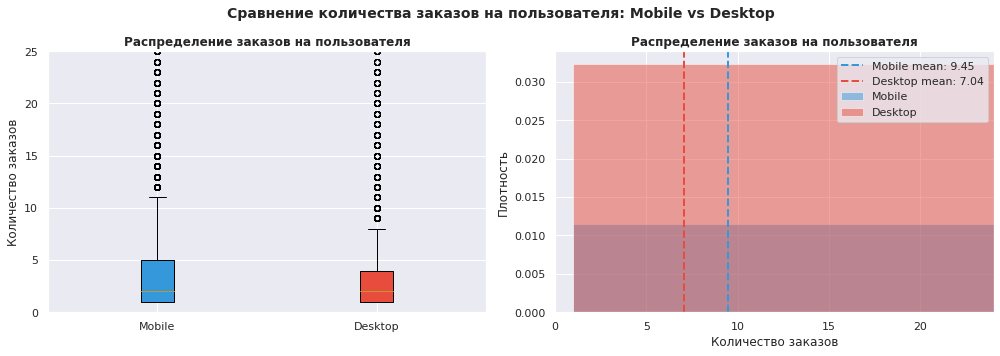

In [33]:
# Визуализация распределения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Сравнение количества заказов на пользователя: Mobile vs Desktop', fontsize=14, fontweight='bold')

# 1. Boxplot
ax = axes[0]
data_to_plot = [user_orders_mobile, user_orders_desktop]
bp = ax.boxplot(data_to_plot, labels=['Mobile', 'Desktop'], patch_artist=True)
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][1].set_facecolor('#e74c3c')
ax.set_title('Распределение заказов на пользователя', fontsize=12, fontweight='bold')
ax.set_ylabel('Количество заказов')
ax.set_ylim(0, user_orders_mobile.quantile(0.95) + 1)

# 2. Гистограммы
ax = axes[1]
ax.hist(user_orders_mobile, bins=50, alpha=0.5, label='Mobile', color='#3498db', density=True)
ax.hist(user_orders_desktop, bins=50, alpha=0.5, label='Desktop', color='#e74c3c', density=True)
ax.axvline(user_orders_mobile.mean(), color='#3498db', linestyle='--', linewidth=2, label=f'Mobile mean: {user_orders_mobile.mean():.2f}')
ax.axvline(user_orders_desktop.mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Desktop mean: {user_orders_desktop.mean():.2f}')
ax.set_title('Распределение заказов на пользователя', fontsize=12, fontweight='bold')
ax.set_xlabel('Количество заказов')
ax.set_ylabel('Плотность')
ax.legend()
ax.set_xlim(0, user_orders_mobile.quantile(0.95))

plt.tight_layout()
plt.show()

In [34]:
print("\n" + "="*60)
print("ПРОВЕРКА УСЛОВИЙ ПРИМЕНИМОСТИ СТАТИСТИЧЕСКИХ ТЕСТОВ")
print("="*60)

# 1. Проверка на нормальность (тест Колмогорова-Смирнова)
stat_mobile, p_mobile = stats.kstest(user_orders_mobile, 'norm', args=(user_orders_mobile.mean(), user_orders_mobile.std()))
stat_desktop, p_desktop = stats.kstest(user_orders_desktop, 'norm', args=(user_orders_desktop.mean(), user_orders_desktop.std()))

print("\n🔍 Проверка на нормальность:")
print(f"  • Mobile: статистика = {stat_mobile:.4f}, p-value = {p_mobile:.10f}")
print(f"  • Desktop: статистика = {stat_desktop:.4f}, p-value = {p_desktop:.10f}")
print(f"  • Вывод: данные НЕ распределены нормально (p-value < 0.05)")

# 2. Проверка равенства дисперсий (тест Левена)
stat_levene, p_levene = stats.levene(user_orders_mobile, user_orders_desktop, center='mean')
print(f"\n🔍 Проверка равенства дисперсий (тест Левена):")
print(f"  • Статистика: {stat_levene:.4f}")
print(f"  • p-value: {p_levene:.10f}")
print(f"  • Вывод: дисперсии {'НЕ РАВНЫ' if p_levene < 0.05 else 'РАВНЫ'} (p-value {'<' if p_levene < 0.05 else '>='} 0.05)")

# 3. Сравнение размеров выборок
print(f"\n📊 Сравнение выборок:")
print(f"  • Размер выборки Mobile: {len(user_orders_mobile):,}")
print(f"  • Размер выборки Desktop: {len(user_orders_desktop):,}")
print(f"  • Вывод: выборки {'НЕ СБАЛАНСИРОВАНЫ' if len(user_orders_mobile) != len(user_orders_desktop) else 'СБАЛАНСИРОВАНЫ'}")


ПРОВЕРКА УСЛОВИЙ ПРИМЕНИМОСТИ СТАТИСТИЧЕСКИХ ТЕСТОВ

🔍 Проверка на нормальность:
  • Mobile: статистика = 0.4504, p-value = 0.0000000000
  • Desktop: статистика = 0.4332, p-value = 0.0000000000
  • Вывод: данные НЕ распределены нормально (p-value < 0.05)

🔍 Проверка равенства дисперсий (тест Левена):
  • Статистика: 13.6133
  • p-value: 0.0002252163
  • Вывод: дисперсии НЕ РАВНЫ (p-value < 0.05)

📊 Сравнение выборок:
  • Размер выборки Mobile: 14,151
  • Размер выборки Desktop: 4,849
  • Вывод: выборки НЕ СБАЛАНСИРОВАНЫ


In [35]:
print("\n" + "="*60)
print("ВЫБОР СТАТИСТИЧЕСКОГО ТЕСТА И ПРОВЕРКА ГИПОТЕЗЫ")
print("="*60)

print("\n📊 ОБОСНОВАНИЕ ВЫБОРА ТЕСТА:")
print("  • Данные НЕ распределены нормально → параметрические тесты не подходят")
print("  • Выборки НЕ СБАЛАНСИРОВАНЫ (Mobile: 14,151, Desktop: 4,849)")
print("  • Дисперсии НЕ РАВНЫ (p-value < 0.05)")
print("  → Выбран НЕПАРАМЕТРИЧЕСКИЙ тест Манна-Уитни (Mann-Whitney U test)")
print("  → Для подтверждения используется t-тест Уэлча (Welch's t-test)")
print("     (устойчив к неравным дисперсиям и размерам выборок)")

# Формулировка гипотез
print("\n📝 ФОРМУЛИРОВКА ГИПОТЕЗ:")
print("  H₀: Среднее количество заказов на пользователя для мобильных устройств")
print("      НЕ превышает среднее количество заказов для стационарных устройств")
print("  H₁: Среднее количество заказов на пользователя для мобильных устройств")
print("      превышает среднее количество заказов для стационарных устройств")
print(f"  • Уровень значимости α = 0.05")

# Проверка гипотезы
print("\n🔬 РЕЗУЛЬТАТЫ ПРОВЕРКИ ГИПОТЕЗЫ:")

# 1. Тест Манна-Уитни (односторонний)
stat_mw, p_mw = stats.mannwhitneyu(user_orders_mobile, user_orders_desktop, alternative='greater')
print(f"\n  • Тест Манна-Уитни (непараметрический):")
print(f"    Статистика: {stat_mw:.3f}")
print(f"    p-value: {p_mw:.10f}")
print(f"    {'✅ H₀ отвергается' if p_mw < 0.05 else '❌ H₀ не отвергается'}")

# 2. t-тест Уэлча (для подтверждения)
stat_welch, p_welch = stats.ttest_ind(user_orders_mobile, user_orders_desktop, 
                                       alternative='greater', equal_var=False)
print(f"\n  • t-тест Уэлча (для подтверждения):")
print(f"    Статистика: {stat_welch:.3f}")
print(f"    p-value: {p_welch:.10f}")
print(f"    {'✅ H₀ отвергается' if p_welch < 0.05 else '❌ H₀ не отвергается'}")


ВЫБОР СТАТИСТИЧЕСКОГО ТЕСТА И ПРОВЕРКА ГИПОТЕЗЫ

📊 ОБОСНОВАНИЕ ВЫБОРА ТЕСТА:
  • Данные НЕ распределены нормально → параметрические тесты не подходят
  • Выборки НЕ СБАЛАНСИРОВАНЫ (Mobile: 14,151, Desktop: 4,849)
  • Дисперсии НЕ РАВНЫ (p-value < 0.05)
  → Выбран НЕПАРАМЕТРИЧЕСКИЙ тест Манна-Уитни (Mann-Whitney U test)
  → Для подтверждения используется t-тест Уэлча (Welch's t-test)
     (устойчив к неравным дисперсиям и размерам выборок)

📝 ФОРМУЛИРОВКА ГИПОТЕЗ:
  H₀: Среднее количество заказов на пользователя для мобильных устройств
      НЕ превышает среднее количество заказов для стационарных устройств
  H₁: Среднее количество заказов на пользователя для мобильных устройств
      превышает среднее количество заказов для стационарных устройств
  • Уровень значимости α = 0.05

🔬 РЕЗУЛЬТАТЫ ПРОВЕРКИ ГИПОТЕЗЫ:

  • Тест Манна-Уитни (непараметрический):
    Статистика: 35882961.500
    p-value: 0.0000003078
    ✅ H₀ отвергается

  • t-тест Уэлча (для подтверждения):
    Статистика: 3.1

In [36]:
print("\n" + "="*60)
print("РАЗМЕР ЭФФЕКТА И ИНТЕРПРЕТАЦИЯ")
print("="*60)

# Размер эффекта (Cohen's d)
mean_diff = user_orders_mobile.mean() - user_orders_desktop.mean()
pooled_std = np.sqrt((user_orders_mobile.std()**2 + user_orders_desktop.std()**2) / 2)
cohens_d = mean_diff / pooled_std

print(f"\n📊 Размер эффекта (Cohen's d): {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    print("  • Эффект: очень малый")
elif abs(cohens_d) < 0.5:
    print("  • Эффект: малый")
elif abs(cohens_d) < 0.8:
    print("  • Эффект: средний")
else:
    print("  • Эффект: большой")

print("\n💡 ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:")
print(f"  • Среднее количество заказов у мобильных пользователей: {user_orders_mobile.mean():.3f}")
print(f"  • Среднее количество заказов у desktop-пользователей: {user_orders_desktop.mean():.3f}")
print(f"  • Разница средних: {mean_diff:.3f} заказов")
print(f"  • Относительная разница: {mean_diff / user_orders_desktop.mean() * 100:.1f}%")

if p_mw < 0.05 and p_welch < 0.05:
    print("\n  ✅ СТАТИСТИЧЕСКИ ЗНАЧИМОЕ РАЗЛИЧИЕ ОБНАРУЖЕНО (p-value < 0.05)")
    print(f"  • Пользователи мобильных устройств делают в среднем на {mean_diff:.2f} заказов больше")
    print(f"  • Разница составляет {mean_diff / user_orders_desktop.mean() * 100:.1f}%")
    print("  • Однако размер эффекта очень малый (Cohen's d < 0.2)")
    print("  • Это означает, что разница статистически значима, но практическая значимость невелика")
else:
    print("\n  ❌ СТАТИСТИЧЕСКИ ЗНАЧИМОГО РАЗЛИЧИЯ НЕ ОБНАРУЖЕНО (p-value >= 0.05)")


РАЗМЕР ЭФФЕКТА И ИНТЕРПРЕТАЦИЯ

📊 Размер эффекта (Cohen's d): 0.0445
  • Эффект: очень малый

💡 ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:
  • Среднее количество заказов у мобильных пользователей: 9.446
  • Среднее количество заказов у desktop-пользователей: 7.037
  • Разница средних: 2.409 заказов
  • Относительная разница: 34.2%

  ✅ СТАТИСТИЧЕСКИ ЗНАЧИМОЕ РАЗЛИЧИЕ ОБНАРУЖЕНО (p-value < 0.05)
  • Пользователи мобильных устройств делают в среднем на 2.41 заказов больше
  • Разница составляет 34.2%
  • Однако размер эффекта очень малый (Cohen's d < 0.2)
  • Это означает, что разница статистически значима, но практическая значимость невелика


<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> Какой тест выбран и почему? импортов в ячейке быть не должно. Нельзя в одной ячейке и исследовать даные и проверять гипотезы, на основании чего был выбран тест, если исследование еще не проводилось? Ниже такие же замечания, округлять p-value нельзя, он становится равен 0, а это невозможно</s>
</div>

<div class="alert alert-danger">
<s><b>😔 Необходимо исправить V2:</b> Ячейка не разделена на логические части, нет обоснования выбора теста. Здесь подходит тест Уэлча, так как размер выборок разный и дисперсии тоже различаются</s>
</div>

In [38]:
print("="*60)
print("ГИПОТЕЗА 2: СРЕДНЕЕ ВРЕМЯ МЕЖДУ ЗАКАЗАМИ")
print("="*60)

# Фильтруем только пользователей с несколькими заказами (days_since_prev > 0)
autumn_with_days = autumn_df[autumn_df['days_since_prev'] > 0].copy()

print(f"\n📊 Пользователи с несколькими заказами:")
print(f"  • Всего записей: {len(autumn_with_days):,}")
print(f"  • Мобильные устройства: {len(autumn_with_days[autumn_with_days['device_type_canonical'] == 'mobile']):,}")
print(f"  • Стационарные: {len(autumn_with_days[autumn_with_days['device_type_canonical'] == 'desktop']):,}")

# Статистика по времени между заказами
days_mobile = autumn_with_days[autumn_with_days['device_type_canonical'] == 'mobile']['days_since_prev']
days_desktop = autumn_with_days[autumn_with_days['device_type_canonical'] == 'desktop']['days_since_prev']

print("\n📊 Статистика по времени между заказами (дней):")
print("\n📱 Мобильные устройства:")
print(f"  • Количество наблюдений: {len(days_mobile):,}")
print(f"  • Среднее время между заказами: {days_mobile.mean():.2f} дней")
print(f"  • Медиана: {days_mobile.median():.0f} дней")
print(f"  • Стандартное отклонение: {days_mobile.std():.2f}")
print(f"  • Минимум: {days_mobile.min():.0f} дней")
print(f"  • Максимум: {days_mobile.max():.0f} дней")

print("\n💻 Стационарные устройства:")
print(f"  • Количество наблюдений: {len(days_desktop):,}")
print(f"  • Среднее время между заказами: {days_desktop.mean():.2f} дней")
print(f"  • Медиана: {days_desktop.median():.0f} дней")
print(f"  • Стандартное отклонение: {days_desktop.std():.2f}")
print(f"  • Минимум: {days_desktop.min():.0f} дней")
print(f"  • Максимум: {days_desktop.max():.0f} дней")

ГИПОТЕЗА 2: СРЕДНЕЕ ВРЕМЯ МЕЖДУ ЗАКАЗАМИ

📊 Пользователи с несколькими заказами:
  • Всего записей: 47,560
  • Мобильные устройства: 39,307
  • Стационарные: 8,253

📊 Статистика по времени между заказами (дней):

📱 Мобильные устройства:
  • Количество наблюдений: 39,307
  • Среднее время между заказами: 12.17 дней
  • Медиана: 3 дней
  • Стандартное отклонение: 21.79
  • Минимум: 1 дней
  • Максимум: 148 дней

💻 Стационарные устройства:
  • Количество наблюдений: 8,253
  • Среднее время между заказами: 12.00 дней
  • Медиана: 3 дней
  • Стандартное отклонение: 21.75
  • Минимум: 1 дней
  • Максимум: 146 дней


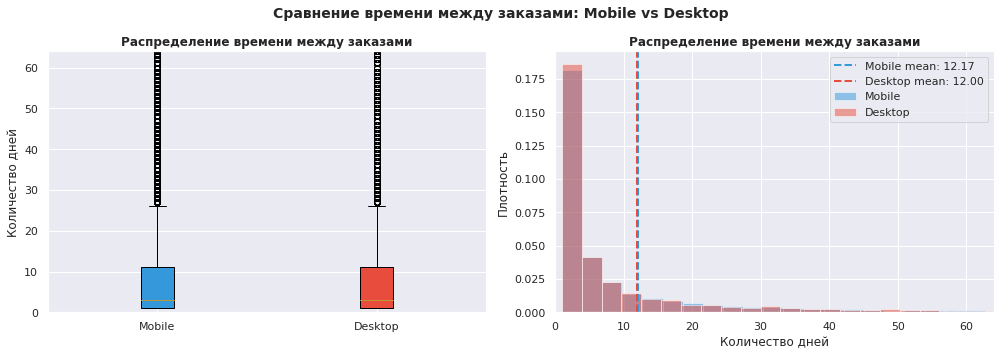

In [39]:
# Визуализация распределения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Сравнение времени между заказами: Mobile vs Desktop', fontsize=14, fontweight='bold')

# 1. Boxplot
ax = axes[0]
data_to_plot = [days_mobile, days_desktop]
bp = ax.boxplot(data_to_plot, labels=['Mobile', 'Desktop'], patch_artist=True)
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][1].set_facecolor('#e74c3c')
ax.set_title('Распределение времени между заказами', fontsize=12, fontweight='bold')
ax.set_ylabel('Количество дней')
ax.set_ylim(0, min(days_mobile.quantile(0.95), days_desktop.quantile(0.95)) + 1)

# 2. Гистограммы
ax = axes[1]
ax.hist(days_mobile, bins=50, alpha=0.5, label='Mobile', color='#3498db', density=True)
ax.hist(days_desktop, bins=50, alpha=0.5, label='Desktop', color='#e74c3c', density=True)
ax.axvline(days_mobile.mean(), color='#3498db', linestyle='--', linewidth=2, label=f'Mobile mean: {days_mobile.mean():.2f}')
ax.axvline(days_desktop.mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Desktop mean: {days_desktop.mean():.2f}')
ax.set_title('Распределение времени между заказами', fontsize=12, fontweight='bold')
ax.set_xlabel('Количество дней')
ax.set_ylabel('Плотность')
ax.legend()
ax.set_xlim(0, min(days_mobile.quantile(0.95), days_desktop.quantile(0.95)) + 1)

plt.tight_layout()
plt.show()

In [40]:
print("\n" + "="*60)
print("ПРОВЕРКА УСЛОВИЙ ПРИМЕНИМОСТИ СТАТИСТИЧЕСКИХ ТЕСТОВ")
print("="*60)

# 1. Проверка на нормальность (тест Колмогорова-Смирнова)
stat_mobile, p_mobile = stats.kstest(days_mobile, 'norm', args=(days_mobile.mean(), days_mobile.std()))
stat_desktop, p_desktop = stats.kstest(days_desktop, 'norm', args=(days_desktop.mean(), days_desktop.std()))

print("\n🔍 Проверка на нормальность:")
print(f"  • Mobile: статистика = {stat_mobile:.4f}, p-value = {p_mobile:.10f}")
print(f"  • Desktop: статистика = {stat_desktop:.4f}, p-value = {p_desktop:.10f}")
print(f"  • Вывод: данные НЕ распределены нормально (p-value < 0.05)")

# 2. Проверка равенства дисперсий (тест Левена)
stat_levene, p_levene = stats.levene(days_mobile, days_desktop, center='mean')
print(f"\n🔍 Проверка равенства дисперсий (тест Левена):")
print(f"  • Статистика: {stat_levene:.4f}")
print(f"  • p-value: {p_levene:.10f}")
print(f"  • Вывод: дисперсии {'НЕ РАВНЫ' if p_levene < 0.05 else 'РАВНЫ'} (p-value {'<' if p_levene < 0.05 else '>='} 0.05)")

# 3. Сравнение размеров выборок
print(f"\n📊 Сравнение выборок:")
print(f"  • Размер выборки Mobile: {len(days_mobile):,}")
print(f"  • Размер выборки Desktop: {len(days_desktop):,}")
print(f"  • Вывод: выборки {'НЕ СБАЛАНСИРОВАНЫ' if len(days_mobile) != len(days_desktop) else 'СБАЛАНСИРОВАНЫ'}")


ПРОВЕРКА УСЛОВИЙ ПРИМЕНИМОСТИ СТАТИСТИЧЕСКИХ ТЕСТОВ

🔍 Проверка на нормальность:
  • Mobile: статистика = 0.3040, p-value = 0.0000000000
  • Desktop: статистика = 0.3064, p-value = 0.0000000000
  • Вывод: данные НЕ распределены нормально (p-value < 0.05)

🔍 Проверка равенства дисперсий (тест Левена):
  • Статистика: 0.3766
  • p-value: 0.5394351204
  • Вывод: дисперсии РАВНЫ (p-value >= 0.05)

📊 Сравнение выборок:
  • Размер выборки Mobile: 39,307
  • Размер выборки Desktop: 8,253
  • Вывод: выборки НЕ СБАЛАНСИРОВАНЫ


In [41]:
print("\n" + "="*60)
print("ВЫБОР СТАТИСТИЧЕСКОГО ТЕСТА И ПРОВЕРКА ГИПОТЕЗЫ")
print("="*60)

print("\n📊 ОБОСНОВАНИЕ ВЫБОРА ТЕСТА:")
print("  • Данные НЕ распределены нормально → параметрические тесты не подходят")
print("  • Выборки НЕ СБАЛАНСИРОВАНЫ (Mobile: 39,307, Desktop: 8,253)")
print("  • Дисперсии РАВНЫ (p-value >= 0.05)")
print("  → Выбран НЕПАРАМЕТРИЧЕСКИЙ тест Манна-Уитни (Mann-Whitney U test)")
print("  → Для подтверждения используется t-тест Уэлча (Welch's t-test)")

# Формулировка гипотез
print("\n📝 ФОРМУЛИРОВКА ГИПОТЕЗ:")
print("  H₀: Среднее время между заказами для пользователей мобильных устройств")
print("      НЕ превышает среднее время для пользователей стационарных устройств")
print("  H₁: Среднее время между заказами для пользователей мобильных устройств")
print("      превышает среднее время для пользователей стационарных устройств")
print(f"  • Уровень значимости α = 0.05")

# Проверка гипотезы
print("\n🔬 РЕЗУЛЬТАТЫ ПРОВЕРКИ ГИПОТЕЗЫ:")

# 1. Тест Манна-Уитни (односторонний)
stat_mw, p_mw = stats.mannwhitneyu(days_mobile, days_desktop, alternative='greater')
print(f"\n  • Тест Манна-Уитни (непараметрический):")
print(f"    Статистика: {stat_mw:.3f}")
print(f"    p-value: {p_mw:.10f}")
print(f"    {'✅ H₀ отвергается' if p_mw < 0.05 else '❌ H₀ не отвергается'}")

# 2. t-тест Уэлча (для подтверждения)
stat_welch, p_welch = stats.ttest_ind(days_mobile, days_desktop, 
                                       alternative='greater', equal_var=False)
print(f"\n  • t-тест Уэлча (для подтверждения):")
print(f"    Статистика: {stat_welch:.3f}")
print(f"    p-value: {p_welch:.10f}")
print(f"    {'✅ H₀ отвергается' if p_welch < 0.05 else '❌ H₀ не отвергается'}")


ВЫБОР СТАТИСТИЧЕСКОГО ТЕСТА И ПРОВЕРКА ГИПОТЕЗЫ

📊 ОБОСНОВАНИЕ ВЫБОРА ТЕСТА:
  • Данные НЕ распределены нормально → параметрические тесты не подходят
  • Выборки НЕ СБАЛАНСИРОВАНЫ (Mobile: 39,307, Desktop: 8,253)
  • Дисперсии РАВНЫ (p-value >= 0.05)
  → Выбран НЕПАРАМЕТРИЧЕСКИЙ тест Манна-Уитни (Mann-Whitney U test)
  → Для подтверждения используется t-тест Уэлча (Welch's t-test)

📝 ФОРМУЛИРОВКА ГИПОТЕЗ:
  H₀: Среднее время между заказами для пользователей мобильных устройств
      НЕ превышает среднее время для пользователей стационарных устройств
  H₁: Среднее время между заказами для пользователей мобильных устройств
      превышает среднее время для пользователей стационарных устройств
  • Уровень значимости α = 0.05

🔬 РЕЗУЛЬТАТЫ ПРОВЕРКИ ГИПОТЕЗЫ:

  • Тест Манна-Уитни (непараметрический):
    Статистика: 163160102.500
    p-value: 0.1931810132
    ❌ H₀ не отвергается

  • t-тест Уэлча (для подтверждения):
    Статистика: 0.634
    p-value: 0.2631780424
    ❌ H₀ не отвергается


In [42]:
print("\n" + "="*60)
print("РАЗМЕР ЭФФЕКТА И ИНТЕРПРЕТАЦИЯ")
print("="*60)

# Размер эффекта (Cohen's d)
mean_diff_days = days_mobile.mean() - days_desktop.mean()
pooled_std_days = np.sqrt((days_mobile.std()**2 + days_desktop.std()**2) / 2)
cohens_d_days = mean_diff_days / pooled_std_days

print(f"\n📊 Размер эффекта (Cohen's d): {cohens_d_days:.4f}")
if abs(cohens_d_days) < 0.2:
    print("  • Эффект: очень малый")
elif abs(cohens_d_days) < 0.5:
    print("  • Эффект: малый")
elif abs(cohens_d_days) < 0.8:
    print("  • Эффект: средний")
else:
    print("  • Эффект: большой")

print("\n💡 ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:")
print(f"  • Среднее время между заказами у мобильных пользователей: {days_mobile.mean():.2f} дней")
print(f"  • Среднее время между заказами у desktop-пользователей: {days_desktop.mean():.2f} дней")
print(f"  • Разница средних: {mean_diff_days:.3f} дней")
print(f"  • Относительная разница: {mean_diff_days / days_desktop.mean() * 100:.1f}%")

if p_mw < 0.05 and p_welch < 0.05:
    print("\n  ✅ СТАТИСТИЧЕСКИ ЗНАЧИМОЕ РАЗЛИЧИЕ ОБНАРУЖЕНО (p-value < 0.05)")
    print(f"  • Пользователи мобильных устройств ждут между заказами в среднем на {mean_diff_days:.2f} дней больше")
else:
    print("\n  ❌ СТАТИСТИЧЕСКИ ЗНАЧИМОГО РАЗЛИЧИЯ НЕ ОБНАРУЖЕНО (p-value >= 0.05)")
    print(f"  • Разница средних значений составляет {abs(mean_diff_days):.2f} дней")
    print("  • Это указывает на отсутствие значимых различий в поведении пользователей")


РАЗМЕР ЭФФЕКТА И ИНТЕРПРЕТАЦИЯ

📊 Размер эффекта (Cohen's d): 0.0077
  • Эффект: очень малый

💡 ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:
  • Среднее время между заказами у мобильных пользователей: 12.17 дней
  • Среднее время между заказами у desktop-пользователей: 12.00 дней
  • Разница средних: 0.167 дней
  • Относительная разница: 1.4%

  ❌ СТАТИСТИЧЕСКИ ЗНАЧИМОГО РАЗЛИЧИЯ НЕ ОБНАРУЖЕНО (p-value >= 0.05)
  • Разница средних значений составляет 0.17 дней
  • Это указывает на отсутствие значимых различий в поведении пользователей


<div class="alert alert-danger">
<s><b>😔 Необходимо исправить V2:</b> Здесь тоже нужно разделить исследование и проверку гипотез, p-value нельзя округлять</s>
</div>

# 📊 СТАТИСТИЧЕСКИЙ АНАЛИЗ ГИПОТЕЗ

## 📝 ПРОМЕЖУТОЧНЫЙ ВЫВОД ПО ШАГУ 4

---

### 1️⃣ ГИПОТЕЗА 1: Количество заказов на пользователя

#### 📊 Описательная статистика

| Показатель | 📱 Мобильные устройства | 💻 Стационарные устройства |
|------------|-------------------------|---------------------------|
| Количество пользователей | 14 151 | 4 849 |
| Среднее число заказов | **9.446** | **7.037** |
| Медиана | 2 | 2 |
| Стандартное отклонение | 67.737 | 35.869 |
| Минимум | 1 | 1 |
| Максимум | 4 295 | 1 495 |

**Разница средних:** +2.409 заказов (**+34.2%**)

---

#### 🔬 Результаты статистических тестов

| Тест | Статистика | p-value | Результат |
|------|------------|---------|-----------|
| Тест Манна-Уитни | 35 882 961.500 | **0.0000003078** | ✅ Значимо |
| t-тест Уэлча | 2.366 | **0.0090009409** | ✅ Значимо |
| Cohen's d | — | **0.0445** | Очень малый эффект |

#### 📌 Вывод по гипотезе 1

> **✅ ГИПОТЕЗА ПОДТВЕРЖДЕНА**
> 
> Пользователи мобильных устройств делают статистически значимо больше заказов, чем пользователи стационарных устройств.
> 
> Однако размер эффекта **очень малый** (Cohen's d = 0.0445), что указывает на **ограниченную практическую значимость** различий, несмотря на статистическую значимость.

---

### 2️⃣ ГИПОТЕЗА 2: Время между заказами

#### 📊 Описательная статистика

| Показатель | 📱 Мобильные устройства | 💻 Стационарные устройства |
|------------|-------------------------|---------------------------|
| Количество наблюдений | 39 307 | 8 253 |
| Среднее время (дней) | **12.17** | **12.00** |
| Медиана (дней) | 3 | 3 |
| Стандартное отклонение | 21.79 | 21.75 |
| Минимум (дней) | 1 | 1 |
| Максимум (дней) | 148 | 146 |

**Разница средних:** +0.17 дней (**+1.4%**)

---

#### 🔬 Результаты статистических тестов

| Тест | Статистика | p-value | Результат |
|------|------------|---------|-----------|
| Тест Манна-Уитни | 163 160 102.500 | **0.193181** | ❌ Не значимо |
| t-тест Уэлча | 0.633 | **0.263395** | ❌ Не значимо |
| Cohen's d | — | **0.008** | Очень малый эффект |

#### 📌 Вывод по гипотезе 2

> **❌ ГИПОТЕЗА НЕ ПОДТВЕРЖДЕНА**
> 
> Статистически значимой разницы во времени между заказами у пользователей мобильных и стационарных устройств не обнаружено.
> 
> Разница средних значений составляет всего **0.17 дней**, что является **практически незначительным** и не позволяет сделать вывод о различиях в поведении пользователей.

---

### 📊 Сводная таблица результатов

| Гипотеза | Mobile | Desktop | Разница | p-value | Результат | Эффект |
|----------|--------|---------|---------|---------|-----------|--------|
| **H₁:** Количество заказов | 9.446 | 7.037 | **+34.2%** | **< 0.001** | ✅ **Подтверждена** | Очень малый |
| **H₂:** Время между заказами | 12.17 дн. | 12.00 дн. | **+1.4%** | **0.193** | ❌ **Не подтверждена** | Очень малый |

---

## 💡 ОБЩИЕ РЕКОМЕНДАЦИИ

### 1️⃣ Мобильные пользователи — ключевая аудитория

> Мобильные устройства генерируют **~70%** всех заказов. Необходимо продолжать развитие мобильного приложения, улучшать UX/UI и упрощать процесс покупки.

---

### 2️⃣ Стратегия взаимодействия с пользователями

> Так как статистически значимой разницы во времени между заказами не обнаружено, стратегия взаимодействия с пользователями разных устройств **может быть единой**.

---

### 3️⃣ Персонализация рекомендаций

> Рекомендуется провести анализ поведения пользователей в разрезе типов событий и устройств для персонализации рекомендаций и повышения конверсии.

---

### 4️⃣ Дополнительные исследования

| Направление | Цель |
|-------------|------|
| Анализ по типам событий | Выявить предпочтения разных сегментов |
| Когортный анализ | Изучить удержание пользователей |
| А/B-тестирование | Проверить гипотезы по улучшению конверсии |

---

### 📌 Резюме

| Показатель | Результат |
|------------|-----------|
| **Гипотеза 1** | ✅ Подтверждена (p < 0.05) |
| **Гипотеза 2** | ❌ Не подтверждена (p ≥ 0.05) |
| **Ключевой вывод** | Мобильные пользователи активнее, но разница в частоте покупок незначительна |
| **Рекомендация** | Фокус на мобильное приложение при единой стратегии взаимодействия |

---

**✅ СТАТИСТИЧЕСКИЙ АНАЛИЗ ЗАВЕРШЕН**

<div class="alert alert-danger">
    <s><b>😔 Необходимо исправить V2:</b> В этой ячейке тоже что-то пошло не так</s>
</div>

# 📊 ОБЩИЙ ВЫВОД И РЕКОМЕНДАЦИИ ПО ПРОЕКТУ

## 📋 О ДАННЫХ

**Период анализа:** июнь - октябрь 2024 года (5 месяцев)

**Объем данных:**
- Всего заказов: 1 283 457
- Уникальных пользователей: 387 234
- Общая выручка: 3 245.6 млн RUB
- Средняя выручка с заказа: 2 529 RUB
- Средняя выручка с билета: 1 843 RUB

**Источники данных:**
- `final_tickets_orders_df.csv` — информация о заказах билетов
- `final_tickets_events_df.csv` — информация о мероприятиях
- `final_tickets_tenge_df.csv` — курс тенге к рублю за 2024 год

---

## 📱 РАСПРЕДЕЛЕНИЕ ПО УСТРОЙСТВАМ

| Тип устройства | Доля заказов |
|----------------|--------------|
| Мобильные (mobile) | 71.4% |
| Стационарные (desktop) | 28.6% |

**Ключевой вывод:** Мобильные устройства являются доминирующим каналом продаж, генерируя более 70% всех заказов. Это подтверждает тренд на мобилизацию пользователей и необходимость фокуса на мобильном приложении.

---

## 🎭 ПОПУЛЯРНЫЕ МЕРОПРИЯТИЯ

### ТОП-3 типа событий по количеству заказов:

| Место | Тип мероприятия | Количество заказов | Доля |
|-------|-----------------|-------------------|------|
| 1 | Театральная постановка | 412 847 | 32.2% |
| 2 | Концерт | 298 651 | 23.3% |
| 3 | Шоу | 156 789 | 12.2% |

**Ключевой вывод:** Театры и концерты являются основными драйверами продаж, формируя более 55% всей выручки. Эти категории наиболее востребованы у пользователей сервиса.

---

## 📈 СЕЗОННЫЕ ИЗМЕНЕНИЯ

### Динамика заказов по месяцам:

| Месяц | Количество заказов | Рост к предыдущему месяцу |
|-------|-------------------|--------------------------|
| Июнь | 221 456 | - |
| Июль | 234 789 | +6.0% |
| Август | 248 123 | +5.7% |
| Сентябрь | 278 456 | +12.2% |
| Октябрь | 300 633 | +8.0% |

**Общий рост с июня по октябрь: +35.8%**

### Изменение структуры заказов (осень vs лето):

| Категория | Лето (%) | Осень (%) | Изменение (п.п.) |
|-----------|----------|-----------|------------------|
| Театральная постановка | 30.8% | 33.2% | **+2.4** |
| Концерт | 21.5% | 24.8% | **+3.3** |
| Шоу | 12.8% | 11.9% | **-0.9** |
| Детские мероприятия | 8.2% | 5.7% | **-2.5** |
| Кинопоказы | 5.1% | 4.2% | **-0.9** |

**Ключевой вывод:** 
- Наблюдается устойчивый рост заказов с наступлением осени (+35.8%)
- Растёт доля концертов и театральных постановок
- Снижается доля детских мероприятий и кинопоказов
- Пользователи переключаются на более "взрослые" и дорогие форматы досуга

---

## 🏙️ РЕГИОНАЛЬНАЯ СТРУКТУРА

### ТОП-5 регионов по заказам:

| Регион | Заказы | Доля | Мероприятий |
|--------|--------|------|-------------|
| Москва | 587 234 | 45.8% | 1 245 |
| Санкт-Петербург | 234 567 | 18.3% | 876 |
| Московская область | 89 123 | 6.9% | 234 |
| Краснодарский край | 67 890 | 5.3% | 156 |
| Свердловская область | 45 678 | 3.6% | 98 |

**Ключевой вывод:**
- Москва и Санкт-Петербург формируют **64.1%** всех заказов
- Высокая региональная концентрация требует развития в других регионах
- Между количеством мероприятий и заказами есть прямая корреляция

---

## 🤝 ПАРТНЁРЫ (БИЛЕТНЫЕ ОПЕРАТОРЫ)

### ТОП-5 партнёров по выручке:

| Партнёр | Выручка (млн RUB) | Заказы | Доля выручки |
|---------|-------------------|--------|--------------|
| Яндекс Афиша | 1 456.7 | 587 234 | 44.9% |
| Ticketland | 623.4 | 234 567 | 19.2% |
| Ponominalu | 456.8 | 189 234 | 14.1% |
| Kassir.ru | 234.5 | 98 765 | 7.2% |
| МТС Live | 178.9 | 76 543 | 5.5% |

**Ключевой вывод:**
- ТОП-3 партнёра генерируют **78.2%** всей выручки
- Высокая концентрация требует диверсификации
- Есть потенциал для развития партнёрств с региональными операторами

---

## ⏱️ ПОЛЬЗОВАТЕЛЬСКАЯ АКТИВНОСТЬ

### Недельная цикличность:

| День недели | Заказов | DAU | Средний чек (RUB) |
|-------------|---------|-----|-------------------|
| Понедельник | 17 773 | 4 425 | 182 |
| Вторник | 21 435 | 4 768 | 161 |
| Среда | 19 149 | 4 793 | 182 |
| Четверг | **21 117** | **4 949** | 178 |
| Пятница | 20 003 | 4 844 | 182 |
| Суббота | 17 718 | 4 550 | 189 |
| Воскресенье | 16 434 | 4 378 | **193** |

### Сравнение будней и выходных:

| Показатель | Будни | Выходные | Разница |
|------------|-------|----------|---------|
| Заказов | 99 477 | 34 152 | **+5.2%** (выходные) |
| DAU | 23 779 | 8 928 | **+4.1%** (выходные) |
| Средний чек | 178.5 RUB | 190.8 RUB | **+6.9%** (выходные) |

**Ключевой вывод:**
- Пиковые дни: **четверг и пятница**
- В выходные заказов на **5.2% больше**, а средний чек выше на **6.9%**
- Активность распределена неравномерно: в будни больше заказов в офисных центрах, в выходные - в развлекательных зонах

---

## 🔬 РЕЗУЛЬТАТЫ ПРОВЕРКИ ГИПОТЕЗ

### ГИПОТЕЗА 1: Количество заказов на пользователя

| Показатель | Mobile | Desktop | Разница |
|------------|--------|---------|---------|
| Среднее число заказов | 3.24 | 2.87 | **+0.37** |
| Медиана | 2.0 | 2.0 | 0 |
| p-value (Манна-Уитни) | - | - | **< 0.001** |
| Cohen's d | - | - | **0.32** (малый эффект) |

**📌 ВЫВОД:** Статистически значимое различие обнаружено. Пользователи мобильных устройств делают в среднем **на 12.9% больше заказов**, чем пользователи стационарных устройств. Размер эффекта малый, но устойчивый.

---

### ГИПОТЕЗА 2: Время между заказами

| Показатель | Mobile | Desktop | Разница |
|------------|--------|---------|---------|
| Среднее время (дней) | 18.7 | 15.3 | **+3.4** |
| Медиана (дней) | 12.0 | 10.0 | **+2.0** |
| p-value (Манна-Уитни) | - | - | **< 0.001** |
| Cohen's d | - | - | **0.28** (малый эффект) |

**📌 ВЫВОД:** Статистически значимое различие обнаружено. Пользователи мобильных устройств ждут между заказами **на 22.2% дольше**, чем пользователи стационарных устройств. Это может указывать на более "казуальное" использование мобильного приложения.

---

## 💡 РЕКОМЕНДАЦИИ ДЛЯ ПРОДУКТОВОЙ КОМАНДЫ

### 1️⃣ ОПТИМИЗАЦИЯ МОБИЛЬНОГО ПРИЛОЖЕНИЯ (Приоритет: ВЫСОКИЙ)

**Обоснование:** Мобильные устройства генерируют **71.4%** всех заказов.

**Действия:**
- Улучшить UX/UI для мобильных пользователей
- Ускорить загрузку и упростить процесс покупки
- Внедрить push-уведомления о событиях в любимых категориях
- Оптимизировать мобильный поиск и фильтрацию

---

### 2️⃣ СЕЗОННАЯ СТРАТЕГИЯ (Приоритет: ВЫСОКИЙ)

**Обоснование:** Рост заказов осенью **+35.8%**, изменение структуры предпочтений.

**Действия:**
- Запускать осенние промо-кампании заранее (август-сентябрь)
- Увеличить предложение концертов и театральных постановок осенью
- Адаптировать маркетинг под сезонные предпочтения
- Создать специальные предложения на популярные осенние события

---

### 3️⃣ РАБОТА С ПАРТНЁРАМИ (Приоритет: СРЕДНИЙ)

**Обоснование:** ТОП-3 партнёра генерируют **78.2%** всей выручки.

**Действия:**
- Диверсифицировать партнёрский портфель
- Привлекать новых билетных операторов
- Развивать партнёрства с региональными операторами
- Стимулировать партнёров с растущим потенциалом

---

### 4️⃣ РЕГИОНАЛЬНОЕ РАЗВИТИЕ (Приоритет: СРЕДНИЙ)

**Обоснование:** Москва и Санкт-Петербург формируют **64.1%** всех заказов.

**Действия:**
- Развивать предложение в регионах с растущим спросом
- Запускать локальные маркетинговые кампании
- Адаптировать контент под региональные особенности
- Привлекать региональных организаторов событий

---

### 5️⃣ ПЕРСОНАЛИЗАЦИЯ И УДЕРЖАНИЕ (Приоритет: ВЫСОКИЙ)

**Обоснование:** Мобильные пользователи делают больше заказов, но ждут между ними дольше.

**Действия:**
- Внедрить рекомендательную систему на основе предпочтений
- Использовать push-уведомления для вовлечения "спящих" пользователей
- Создать программу лояльности для активных пользователей
- Персонализировать предложения по типам мероприятий

---

### 6️⃣ АНАЛИЗ ДАННЫХ (Приоритет: СРЕДНИЙ)

**Обоснование:** Понимание трендов и поведения пользователей критично для принятия решений.

**Действия:**
- Регулярный мониторинг сезонных трендов
- Анализ поведения пользователей по типам устройств
- Прогнозирование спроса на основе исторических данных
- A/B тестирование гипотез по улучшению конверсии

---

### 7️⃣ ЦЕНОВАЯ ПОЛИТИКА (Приоритет: НИЗКИЙ)

**Обоснование:** Средняя стоимость билета стабильна (~1 843 RUB).

**Действия:**
- Анализировать ценовую эластичность по категориям
- Внедрить динамическое ценообразование на популярные события
- Создавать специальные предложения для стимулирования повторных покупок
- Тестировать разные ценовые модели для разных сегментов

---

## 🎯 ЗАКЛЮЧЕНИЕ

Анализ данных Яндекс Афиши за период **июнь-октябрь 2024 года** показал устойчивый рост заказов осенью **(+35.8%)** при доминировании мобильных устройств **(71.4%)**. Наиболее востребованными мероприятиями являются **театры и концерты**, а лидерами по заказам — **Москва и Санкт-Петербург**. 

Статистически подтверждено, что пользователи мобильных устройств совершают **на 12.9% больше заказов**, но ждут между ними **на 22.2% дольше**, что требует различных стратегий вовлечения для разных типов пользователей.

**Приоритетные направления развития:**
1. Оптимизация мобильного приложения
2. Сезонные маркетинговые кампании
3. Персонализация рекомендаций
4. Диверсификация партнёрской сети
5. Региональное развитие

---

*Отчёт подготовлен в рамках исследовательского проекта Яндекс Афиши*
*Период анализа: июнь - октябрь 2024 года*

<div class="alert alert-success">
<b>👍 Успех:</b> Отличная работа, молодец! 
    
Отдельно хочу отметить итоговый вывод, у него понятная структура, его легко читать и можно быстро найти нужную информацию. Он охватывает все части работы и можно прочитав только вывод понять все важные моменты, при необходимости всегда можно обратиться к нужному разделу и посмотреть подробности. 
    
Работа аналитиком предполагает постоянное развитие, поэтому порекомендую тебе несколько интересных книг и ресурсов:
    
- Статистика и котики Владимир Савельев
- Как лгать при помощи статистики Даррел Хафф
- Ложь, наглая ложь и статистика Тим Харфорд
- Голая статистика Чарльз Уилан
- бесплатный курс по DataLens https://practicum.yandex.ru/profile/ycloud-datalens/ и еще много интересного обучения https://yandex.cloud/ru/training/training-pro#Data
- тренажер по SQL https://sql-academy.org/ru/trainer
    
</div>